In [34]:
import gurobipy as gp
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.io as pio
import numpy as np
import pandas as pd
from gurobipy import GRB

In [35]:
try: 
    from gurobipy import * 
    print("¡Excelente! Gurobi python se instaló correctamente") 
except: 
    print("Hub  o algún problema. Revise nuevamente los videos de instalación") 

¡Excelente! Gurobi python se instaló correctamente


Loading Network

In [36]:
def load_edges_from_csv(path_edges: str):
    """
    CSV esperado: node_id1,node_id2,b,f_max
    b = costo base por arco
    f_max = capacidad base
    """
    edges = pd.read_csv(path_edges)
    edges = edges.rename(columns={
        "node_id1": "i",
        "node_id2": "j",
        "b": "c_base",
        "f_max": "U_base"
    })

    edges["e_id"] = np.arange(len(edges))
    return edges

def load_nodes_from_csv(path_nodes: str):
    """
    CSV esperado:
    node_id,d,p_min,p_max,c_var,is_generator,energy_type,instance
    d = demanda base (si no es generador)
    p_max = capacidad gen máxima (si es generador)
    """
    nodes = pd.read_csv(path_nodes)
    nodes = nodes.rename(columns={"node_id":"node"})
    return nodes

## Scenario Generation

Uncertainty is represented through a set of scenarios \( $\omega$ $\in$ $\Omega$ \).

Each scenario defines a full realization of the system including:

- ($D_{i\omega}$): demand at node ($i$)
- ($U_{e\omega}$): effective capacity of arc ($e$)
- ($c_{e\omega}$): operational cost of arc ($e$)
- ($G_{i\omega}$): available generation at generator node ($i$)

Conceptually, each scenario can be interpreted as a “state of the world”.

First, a large set of scenarios \($W$\) is generated from the uncertainty model.  
Then, this set is reduced to a smaller representative subset \($W'$\) used for optimization.

Defining the world $W$, the baseline for scenarios

In [37]:
def sample_one_scenario_W(nodes, edges, rng,
                          p_crisis=0.15,
                          # mediocristan
                          dem_sigma=0.10,
                          cost_sigma=0.05,
                          p_outage=0.2,
                          cap_drop=0.45,
                          # extremistan
                          crisis_dem_mult_mu=2.0,
                          crisis_dem_mult_sigma=0.25,

                          crisis_cost_mult=1.25,
                          correlated_outage_nodes=None,
                          correlated_outage_prob=0.8):
    """
    Devuelve un escenario ω completo:
    - D_iω para cada nodo de demanda
    - U_eω para cada arco (capacidad efectiva)
    - c_eω para cada arco (costo operativo)
    """

    # 1) checking if its a crisis scenario
    crisis = rng.random() < p_crisis
        #5% Extremistán
        #95% Mediocristán

    # 2) Demand per node: D_iω
    #Base demand
    D = nodes[["node"]].copy()
    D["D_base"] = nodes["d"].fillna(0.0)

    #Generating demand multiplier (M) based on crisis or not
    if not crisis:
        # Mediocristán: M ~ Normal(1, dem_sigma)
        mult = rng.normal(1.0, dem_sigma, size=len(D))
        mult = np.clip(mult, 0.0, None) # not negative demand
    else:
        # Extremistán: multiplicador grande 
        pareto_alpha = 2.0  # ejemplo
        Y = rng.pareto(a=pareto_alpha, size=len(D))
        mult = 1.0 + Y
    
    # only apply multiplier to demand nodes (D_base > 0)
    D["D_w"] = D["D_base"] * mult
    D.loc[D["D_base"] == 0, "D_w"] = 0.0

    # 3) Cost per arc:
    c = edges[["e_id", "c_base"]].copy()

    if not crisis:
        #mediocristán: small noise around base cost
        # financial uncertainty
        cost_mult = rng.normal(1.0, cost_sigma, size=len(c))
        cost_mult = np.clip(cost_mult, 0.1, None)
    else:
        #extremistán: operative cost increase due to crisis (1.25)
        cost_mult = np.ones(len(c)) * crisis_cost_mult
    c["c_w"] = c["c_base"] * cost_mult

    # 4) Capacity per arc:
    U = edges[["e_id", "U_base", "i", "j"]].copy()

    # mediocristán: each arc has prob p_outage of suffering a capacity reduction (cap_drop)

    outage = rng.random(len(U)) < p_outage
    U_mult = np.where(outage, cap_drop, 1.0)
    
    U["U_w"] = U["U_base"] * U_mult
    #extremistán: if crisis, could happen a "correlated attack" that 
    # completely takes down certain critical arcs (around specific nodes)

    if crisis and correlated_outage_nodes is not None:
        # con prob correlated_outage_prob ocurre "ataque" correlacionado
        if rng.random() < correlated_outage_prob:
            affected = U["i"].isin(correlated_outage_nodes) | U["j"].isin(correlated_outage_nodes)
            # tumba esos arcos completamente
            U_mult = np.where(affected, 0.0, U_mult)

    U["U_w"] = U["U_base"] * U_mult
    
    # 5) Capacidad de generación por nodo generador: G_iω
    gen_nodes = nodes[nodes["is_generator"] == True]
    G = nodes[["node"]].copy()
    G["G_base"] = nodes["p_max"].fillna(0.0)

    if not crisis:
        # Mediocristán: pequeña variación en disponibilidad del generador
        gen_mult = rng.normal(1.0, 0.05, size=len(G))
        gen_mult = np.clip(gen_mult, 0.5, 1.0)  # nunca genera más de su p_max
    else:
        # Extremistán: en crisis generadores pueden caer
        gen_mult = rng.uniform(0.3, 1.0, size=len(G))

    G["G_w"] = G["G_base"] * gen_mult
    G.loc[G["G_base"] == 0, "G_w"] = 0.0  # nodos de demanda no generan

    return {
        "crisis": int(crisis),
        "D": D[["node", "D_w"]],
        "U": U[["e_id", "U_w"]],
        "c": c[["e_id", "c_w"]],
        "G": G[["node", "G_w"]]
    }

In [38]:

def generate_massive_W(nodes, edges, n_samples=1000, seed=123,
                       correlated_outage_nodes=None):
    rng = np.random.default_rng(seed)
    scenarios = []
    for _ in range(n_samples):
        sc = sample_one_scenario_W(nodes, edges, rng,
                                   correlated_outage_nodes=correlated_outage_nodes)
        scenarios.append(sc)
    return scenarios


In [39]:
def scenario_features(sc, nodes, edges):
    """
    Convierte escenario a un vector feature para cluster:
    - demanda total
    - % capacidad perdida (promedio)
    - costo medio
    - indicador crisis
    """
    Dtot = sc["D"]["D_w"].sum()

    U_base = edges.set_index("e_id")["U_base"]
    U_eff  = sc["U"].set_index("e_id")["U_w"]
    cap_loss = 1.0 - (U_eff / U_base.replace(0, np.nan)).fillna(1.0)
    cap_loss_mean = cap_loss.mean()

    c_mean = sc["c"]["c_w"].mean()

    return np.array([Dtot, cap_loss_mean, c_mean, sc["crisis"]], dtype=float)

def reduce_to_K_scenarios(scenarios, nodes, edges, K=20, seed=123):
    """
    Reducción simple:
    - extrae features
    - aplica k-means
    - elige como representante el escenario más cercano al centroide (medoid)
    - prob de cada escenario = proporción de puntos asignados
    """
    from sklearn.cluster import KMeans

    X = np.vstack([scenario_features(sc, nodes, edges) for sc in scenarios])
    km = KMeans(n_clusters=K, random_state=seed, n_init=20)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    reps = []
    probs = []
    #encontrar representante de cada cluster
    for k in range(K):
        idx = np.where(labels == k)[0]
        probs.append(len(idx) / len(scenarios))
        # elegir el más cercano al centroide
        dists = np.linalg.norm(X[idx] - centers[k], axis=1)
        rep_idx = idx[np.argmin(dists)]
        reps.append(scenarios[rep_idx])

    return reps, np.array(probs)

In [40]:
def export_Wprime(reps, probs, out_prefix="Wprime"):
    """
    Crea tres tablas:
    - demanda: (omega, node, D_iw)
    - capacidad: (omega, e_id, U_ew)
    - costos: (omega, e_id, c_ew)
    - prob: (omega, p_omega, crisis)
    """
    rows_D, rows_U, rows_c, rows_p, rows_G = [], [], [], [], []

    for w, (sc, p) in enumerate(zip(reps, probs), start=1):
        rows_p.append({"omega": w, "p_omega": float(p), "crisis": sc["crisis"]})

        for _, r in sc["D"].iterrows():
            rows_D.append({"omega": w, "node": int(r["node"]), "D_iw": float(r["D_w"])})
        for _, r in sc["U"].iterrows():
            rows_U.append({"omega": w, "e_id": int(r["e_id"]), "U_ew": float(r["U_w"])})
        for _, r in sc["c"].iterrows():
            rows_c.append({"omega": w, "e_id": int(r["e_id"]), "c_ew": float(r["c_w"])})
        for _, r in sc["G"].iterrows():
            rows_G.append({"omega": w, "node": int(r["node"]), "G_iw": float(r["G_w"])})

    dfD = pd.DataFrame(rows_D)
    dfU = pd.DataFrame(rows_U)
    dfc = pd.DataFrame(rows_c)
    dfp = pd.DataFrame(rows_p)
    dfG = pd.DataFrame(rows_G)

    dfD.to_csv(f"{out_prefix}_D.csv", index=False)
    dfU.to_csv(f"{out_prefix}_U.csv", index=False)
    dfc.to_csv(f"{out_prefix}_c.csv", index=False)
    dfp.to_csv(f"{out_prefix}_p.csv", index=False)
    dfG.to_csv(f"{out_prefix}_G.csv", index=False)

    return dfD, dfU, dfc, dfp, dfG


In [41]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_network_with_hardening(nodes_list, edges_list, arc_i, arc_j, h_solution, title):
    
    G = nx.DiGraph()

    # agregar nodos
    for n in nodes_list:
        G.add_node(n)

    # agregar arcos
    for e in edges_list:
        i = arc_i[e]
        j = arc_j[e]
        G.add_edge(i, j)

    pos = nx.spring_layout(G, seed=42)

    reinforced = []
    normal = []

    for e in edges_list:
        i = arc_i[e]
        j = arc_j[e]
        if h_solution[e] > 0.5:
            reinforced.append((i,j))
        else:
            normal.append((i,j))

    plt.figure(figsize=(8,6))

    nx.draw_networkx_nodes(G, pos, node_size=70)

    nx.draw_networkx_edges(
        G, pos,
        edgelist=normal,
        edge_color="gray",
        arrows=True
    )

    nx.draw_networkx_edges(
        G, pos,
        edgelist=reinforced,
        edge_color="red",
        width=3,
        arrows=True
    )

    #nx.draw_networkx_labels(G, pos)

    plt.title(title)
    plt.show()

## Loading the scenarios

In [42]:
edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")
instance = 69
nodes = nodes[nodes["instance"] == instance].reset_index(drop=True)
gens = nodes[nodes["is_generator"] == True]["node"].to_list()

escenarios_W = generate_massive_W(nodes, edges, n_samples=1000, seed=1,
                                  correlated_outage_nodes=gens)

reps, probs = reduce_to_K_scenarios(escenarios_W, nodes, edges, K=20, seed=1)

dfD, dfU, dfc, dfp,dfG = export_Wprime(reps, probs, out_prefix="Wprime20")


c:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch

omegas_list = dfp["omega"].tolist()
p_vals      = dfp["p_omega"].values
crisis_vals = dfp["crisis"].values
colors      = ["#c0392b" if c else "#2980b9" for c in crisis_vals]
labels      = [f"ω{w}" for w in omegas_list]

D_total   = dfD.groupby("omega")["D_iw"].sum().reindex(omegas_list).values
c_mean_sc = dfc.groupby("omega")["c_ew"].mean().reindex(omegas_list).values
G_total   = dfG.groupby("omega")["G_iw"].sum().reindex(omegas_list).values
deficit   = D_total - G_total

U_base_series = edges.set_index("e_id")["U_base"]
cap_loss_mean, arcos_caidos, arcos_debil = [], [], []
for w in omegas_list:
    U_sc  = dfU[dfU["omega"] == w].set_index("e_id")["U_ew"]
    ratio = (U_sc / U_base_series.replace(0, np.nan)).fillna(1.0)
    loss  = 1.0 - ratio
    cap_loss_mean.append(loss.mean())
    arcos_caidos.append((U_sc == 0).sum())
    arcos_debil.append(((U_sc > 0) & (U_sc < U_base_series)).sum())

cap_loss_mean = np.array(cap_loss_mean)
arcos_caidos  = np.array(arcos_caidos)
arcos_debil   = np.array(arcos_debil)

legend_elements = [
    Patch(facecolor="#c0392b", label="Crisis (Extremistán)"),
    Patch(facecolor="#2980b9", label="Normal (Mediocristán)"),
]

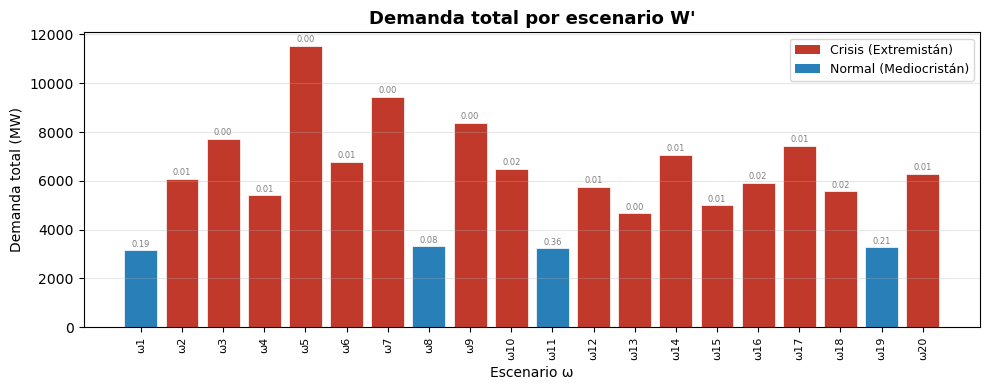

In [44]:
# Demanda total por escenario

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(labels, D_total, color=colors, edgecolor="white", linewidth=0.5)
for bar, p in zip(bars, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{p:.2f}", ha="center", va="bottom", fontsize=6, color="gray")

ax.set_title("Demanda total por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Demanda total (MW)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

The total demand per scenario shows a clear separation between normal and crisis regimes. Normal scenarios (Mediocristán) present moderate demand levels, while crisis scenarios (Extremistán) exhibit significantly higher total demand. This reflects the heavy-tail behavior introduced in the scenario generator, where extreme events produce large demand spikes that stress the network and create potential supply shortages.

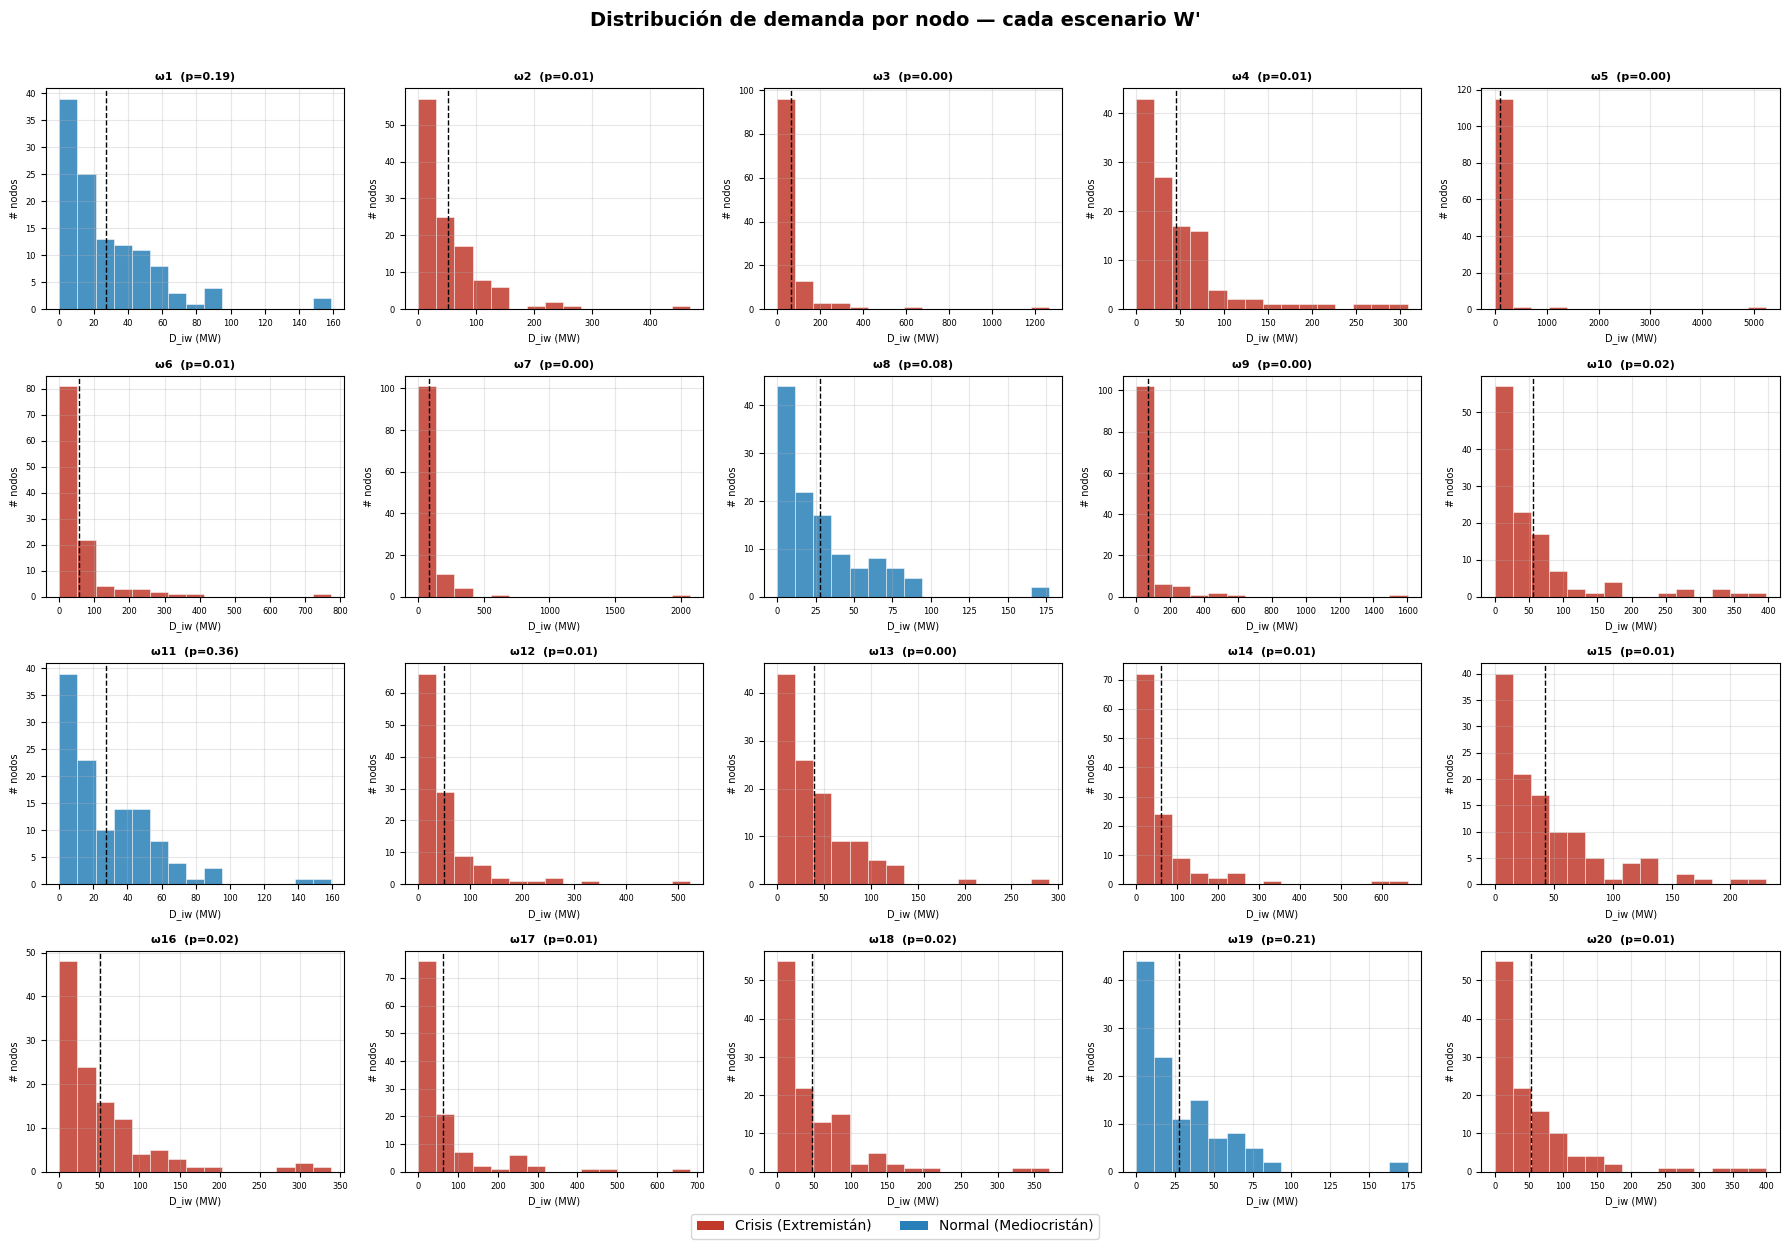

In [45]:
#Demanda

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals = dfD[dfD["omega"] == w]["D_iw"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#2980b9"

    ax.hist(vals, bins=15, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("D_iw (MW)", fontsize=7)
    ax.set_ylabel("# nodos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de demanda por nodo — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
fig.legend(handles=legend_elements, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

The node-level demand distributions reveal strong skewness across scenarios. In crisis scenarios, the histograms show long right tails, indicating that a few nodes experience extremely high demand values. In contrast, normal scenarios remain concentrated around lower values. This confirms that demand uncertainty follows a heavy-tailed pattern, where rare scenarios generate very large loads at certain nodes.

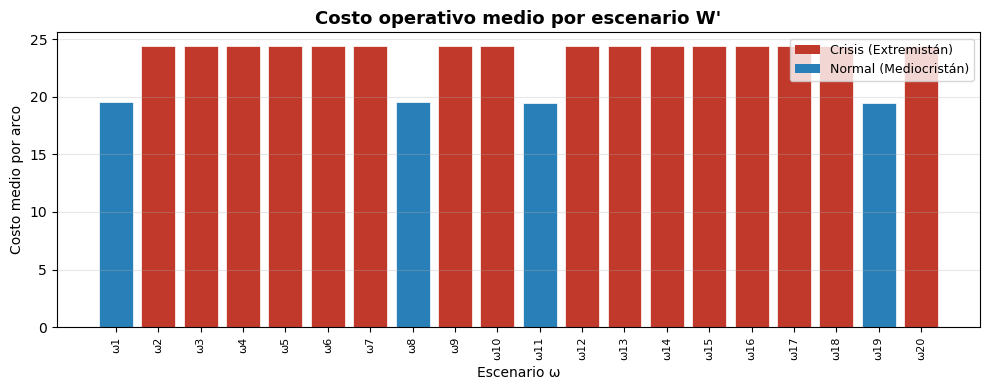

In [46]:
# Costo operativo medio por escenario

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, c_mean_sc, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Costo operativo medio por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Costo medio por arco")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

The average operational cost per arc increases significantly in crisis scenarios compared with normal scenarios. This occurs because crisis regimes apply higher cost multipliers, reflecting financial stress or operational inefficiencies during disruptions. As a result, extreme scenarios not only increase demand but also make power transmission more expensive.

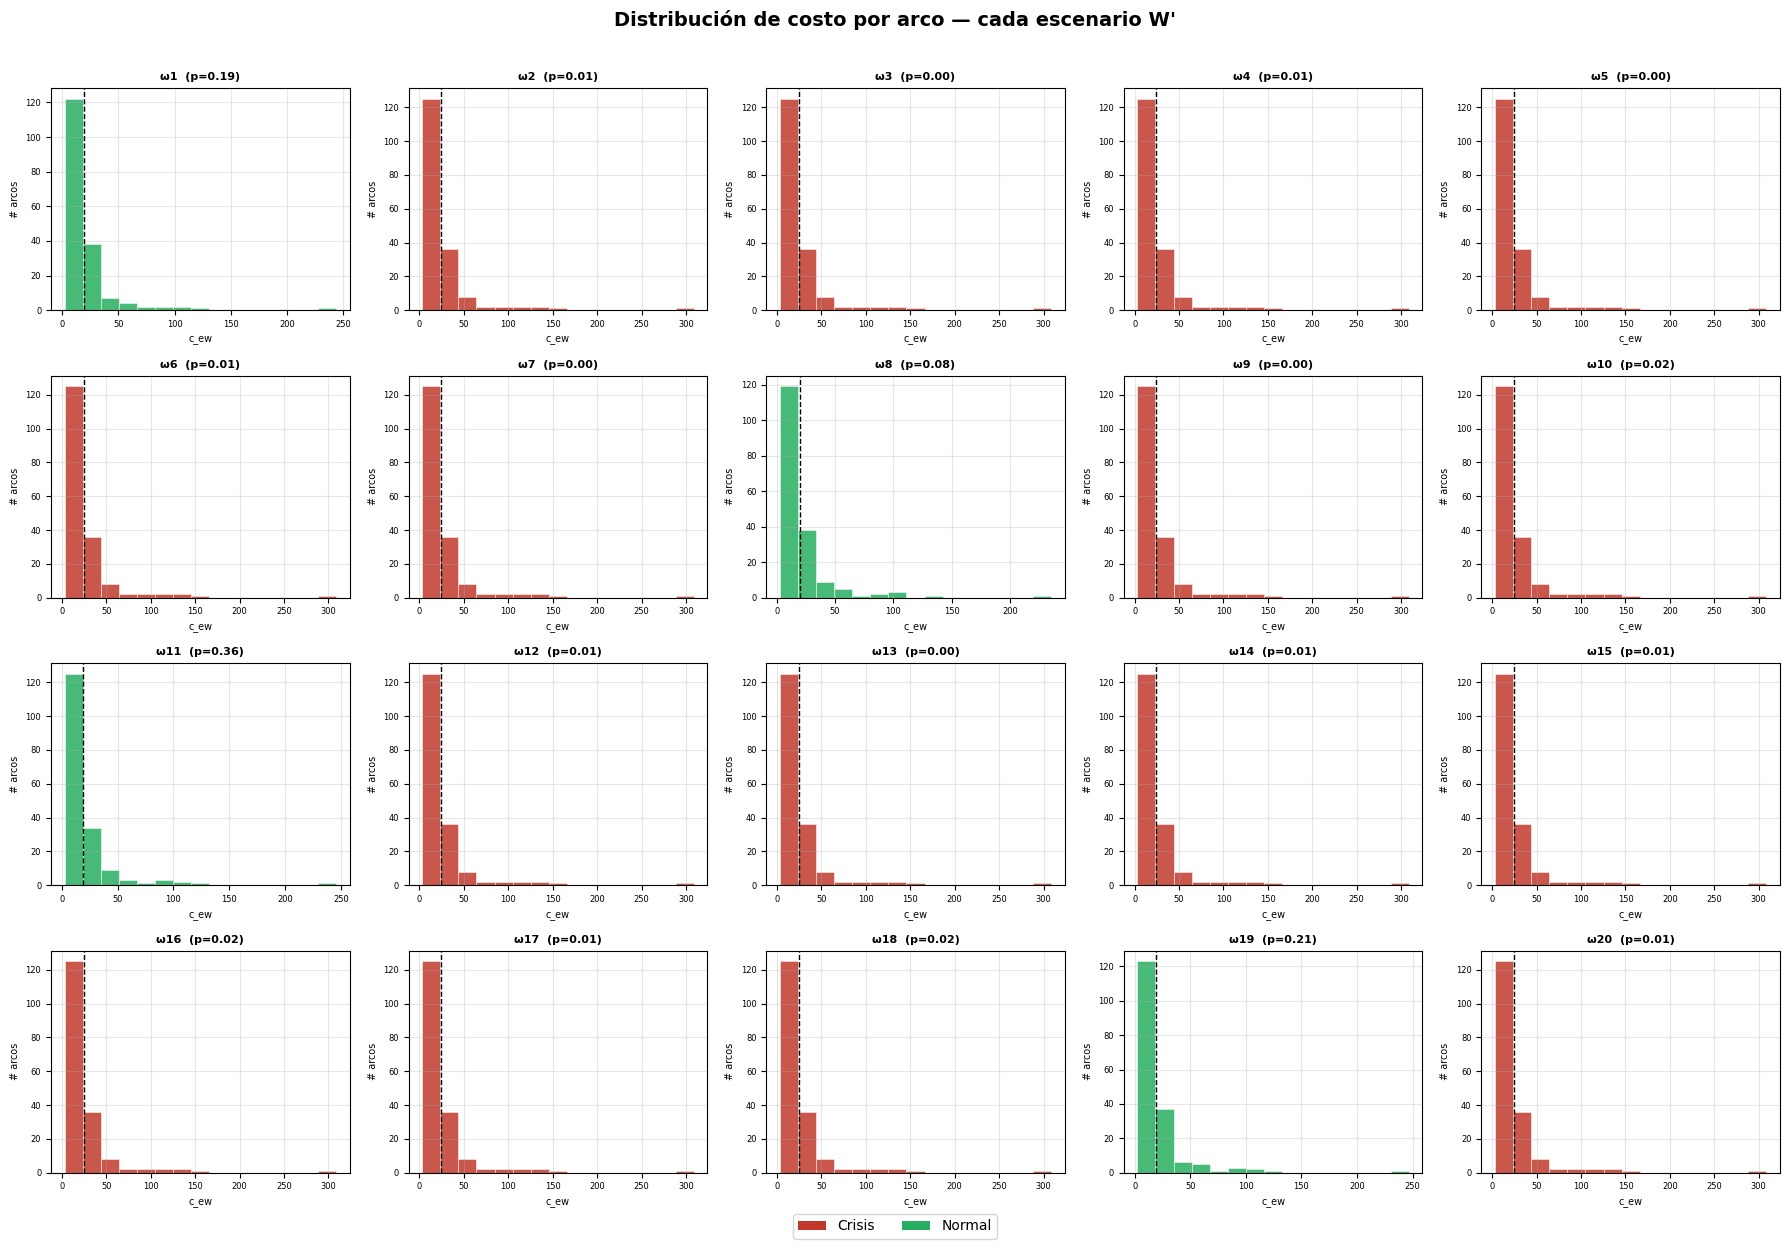

In [47]:
# Costo por escenario

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals = dfc[dfc["omega"] == w]["c_ew"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#27ae60"

    ax.hist(vals, bins=15, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("c_ew", fontsize=7)
    ax.set_ylabel("# arcos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de costo por arco — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
cost_legend = [Patch(facecolor="#c0392b", label="Crisis"),
               Patch(facecolor="#27ae60", label="Normal")]
fig.legend(handles=cost_legend, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

The average operational cost per arc increases significantly in crisis scenarios compared with normal scenarios. This occurs because crisis regimes apply higher cost multipliers, reflecting financial stress or operational inefficiencies during disruptions. As a result, extreme scenarios not only increase demand but also make power transmission more expensive.

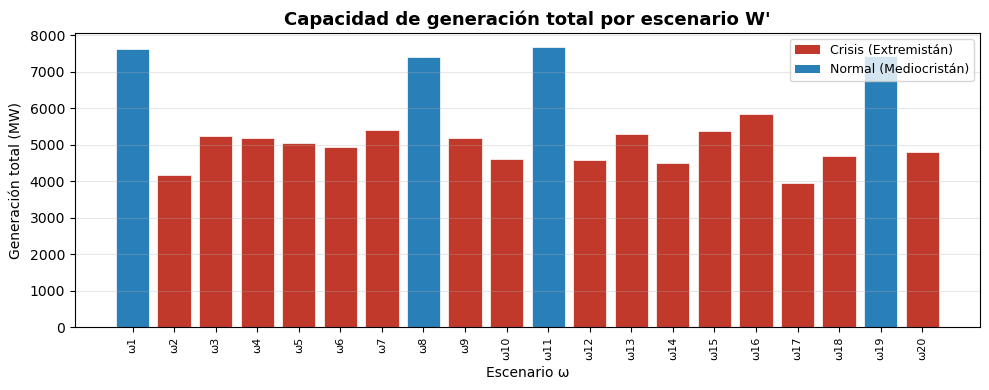

In [48]:
# Capacidad por escenario
fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, G_total, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Capacidad de generación total por escenario W'", fontsize=13, fontweight="bold")
ax.set_ylabel("Generación total (MW)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

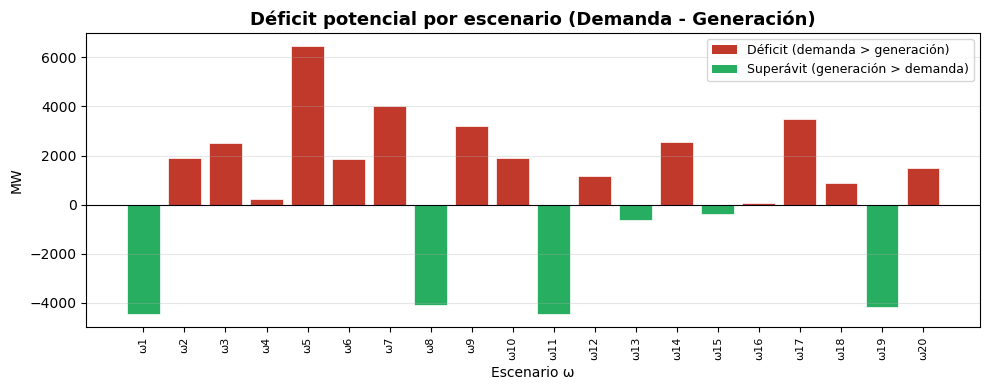

In [49]:
# Deficit potencial por escenario

fig, ax = plt.subplots(figsize=(10, 4))

deficit_colors = ["#c0392b" if d > 0 else "#27ae60" for d in deficit]
ax.bar(labels, deficit, color=deficit_colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Déficit potencial por escenario (Demanda - Generación)", fontsize=13, fontweight="bold")
ax.set_ylabel("MW")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)

deficit_legend = [
    Patch(facecolor="#c0392b", label="Déficit (demanda > generación)"),
    Patch(facecolor="#27ae60", label="Superávit (generación > demanda)"),
]
ax.legend(handles=deficit_legend, fontsize=9)
plt.tight_layout()
plt.show()

The deficit plot highlights the imbalance between demand and generation in each scenario. Positive values indicate scenarios where demand exceeds generation capacity, leading to potential load shedding. Crisis scenarios tend to produce larger deficits, while some normal scenarios show negative values.

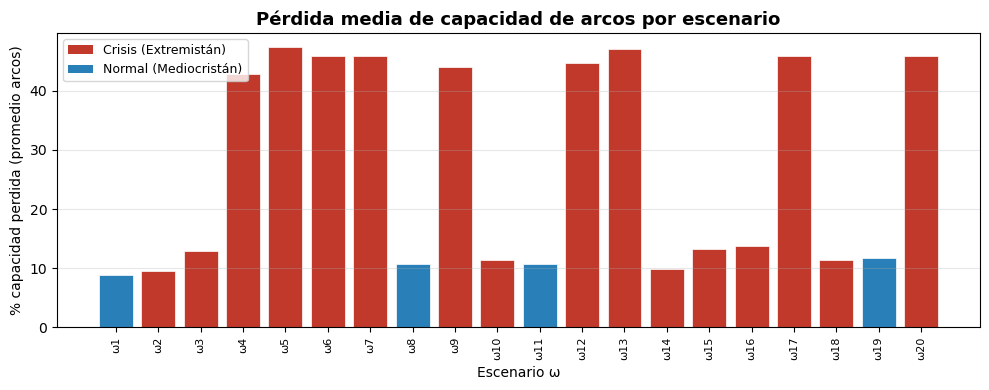

In [50]:
# Pérdida de capacidad por escenario

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, cap_loss_mean * 100, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Pérdida media de capacidad de arcos por escenario", fontsize=13, fontweight="bold")
ax.set_ylabel("% capacidad perdida (promedio arcos)")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

The deficit plot highlights the imbalance between demand and generation in each scenario. Positive values indicate scenarios where demand exceeds generation capacity, leading to potential load shedding. Crisis scenarios tend to produce larger deficits, while some normal scenarios show negative values

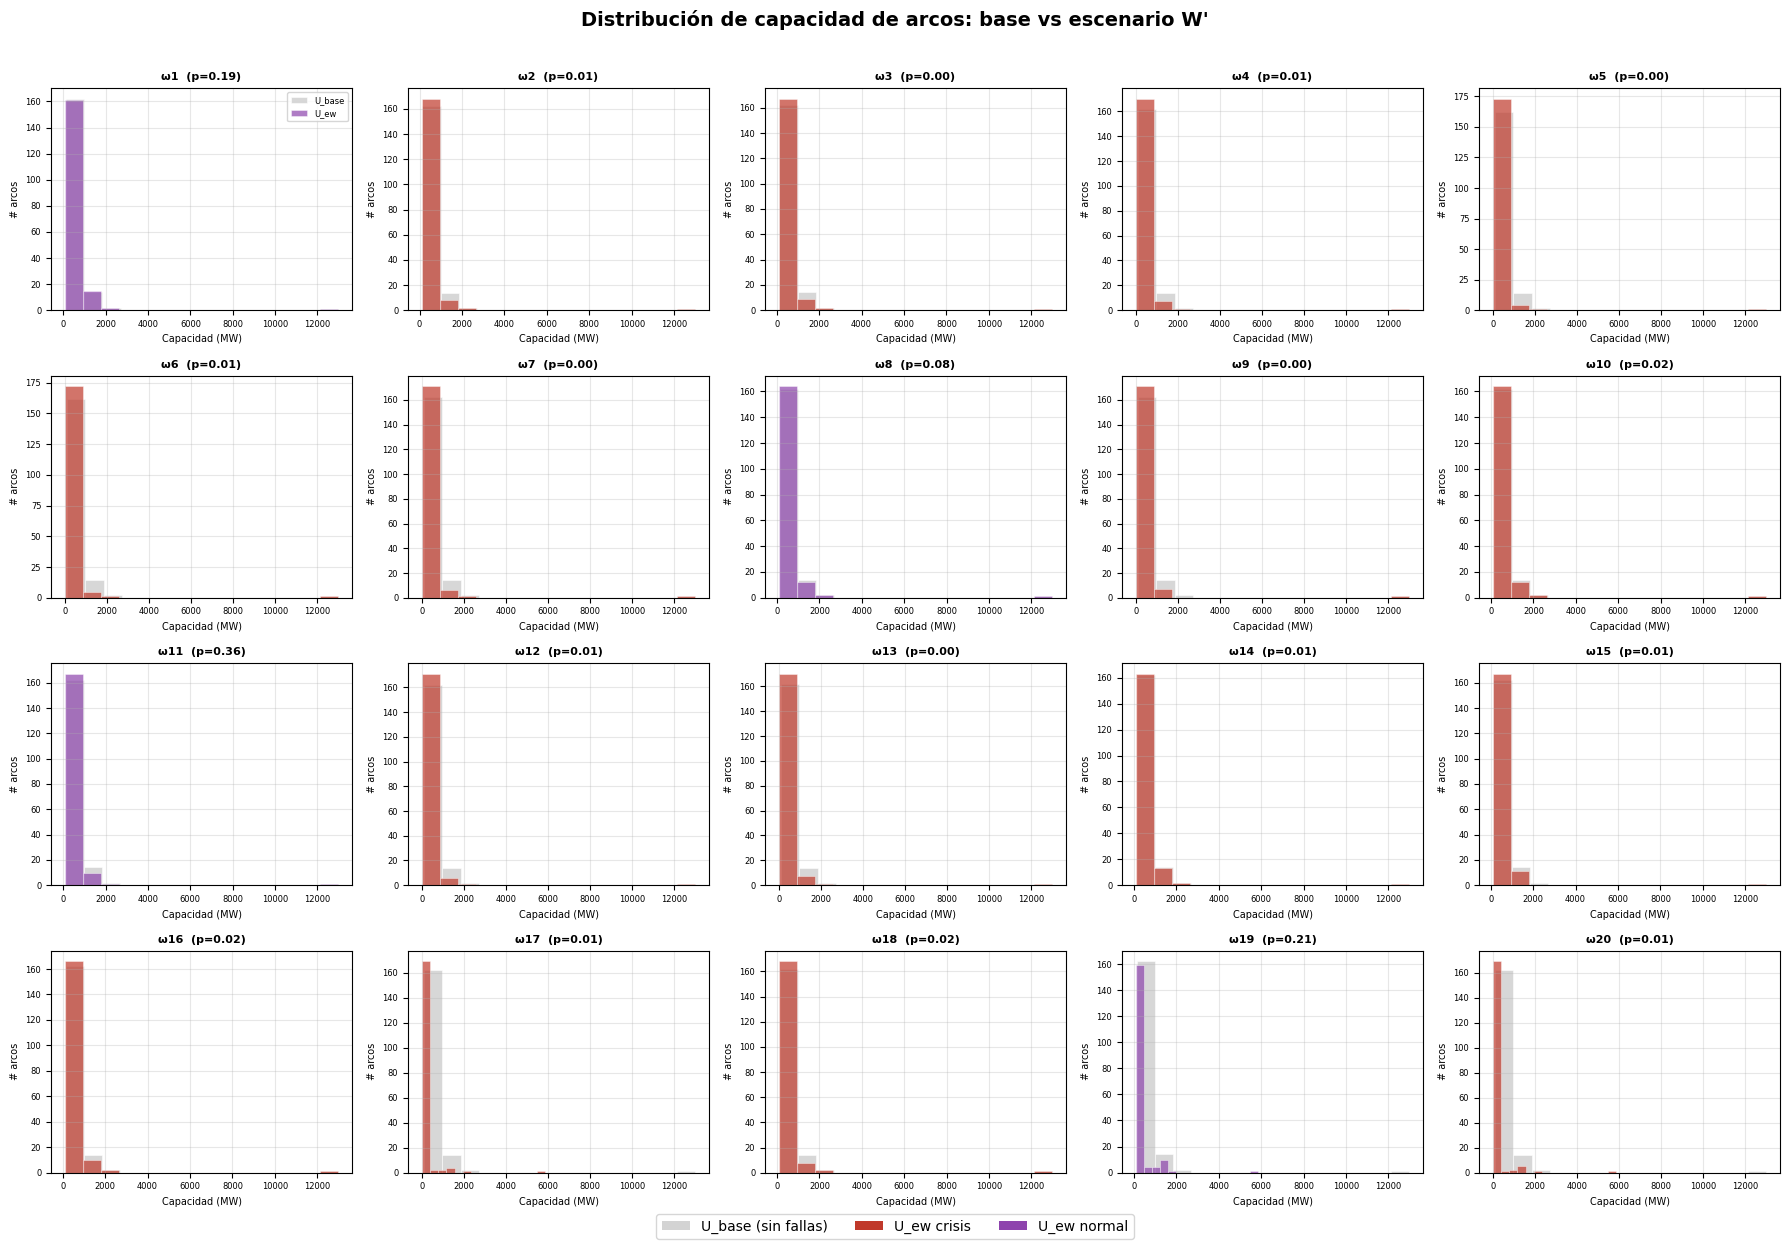

In [51]:
# Capacidad de arcos

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    vals      = dfU[dfU["omega"] == w]["U_ew"].values
    vals_base = U_base_series.values
    crisis    = dfp[dfp["omega"] == w]["crisis"].values[0]
    color     = "#c0392b" if crisis else "#8e44ad"

    ax.hist(vals_base, bins=15, color="lightgray", edgecolor="white",
            linewidth=0.4, alpha=0.9, label="U_base")
    ax.hist(vals, bins=15, color=color, edgecolor="white",
            linewidth=0.4, alpha=0.7, label="U_ew")
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("Capacidad (MW)", fontsize=7)
    ax.set_ylabel("# arcos", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

# leyenda solo en primer subplot
axes[0].legend(fontsize=6)

fig.suptitle("Distribución de capacidad de arcos: base vs escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
cap_legend = [Patch(facecolor="lightgray", label="U_base (sin fallas)"),
              Patch(facecolor="#c0392b", label="U_ew crisis"),
              Patch(facecolor="#8e44ad", label="U_ew normal")]
fig.legend(handles=cap_legend, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

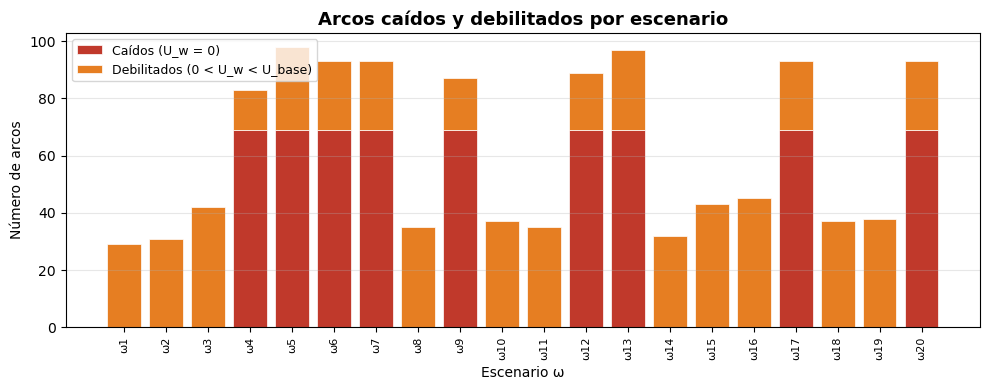

In [52]:
# Arcos caídos vs. debilitados

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(labels, arcos_caidos, label="Caídos (U_w = 0)",
       color="#c0392b", edgecolor="white", linewidth=0.5)
ax.bar(labels, arcos_debil, bottom=arcos_caidos,
       label="Debilitados (0 < U_w < U_base)",
       color="#e67e22", edgecolor="white", linewidth=0.5)

ax.set_title("Arcos caídos y debilitados por escenario", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de arcos")
ax.set_xlabel("Escenario ω")
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The average percentage of capacity loss per scenario is significantly higher in crisis scenarios. This indicates that disruptions such as outages or degraded transmission lines reduce the effective capacity of the network. Normal scenarios show relatively small capacity losses, while crisis scenarios exhibit substantial degradation, which directly limits power flow across the network.

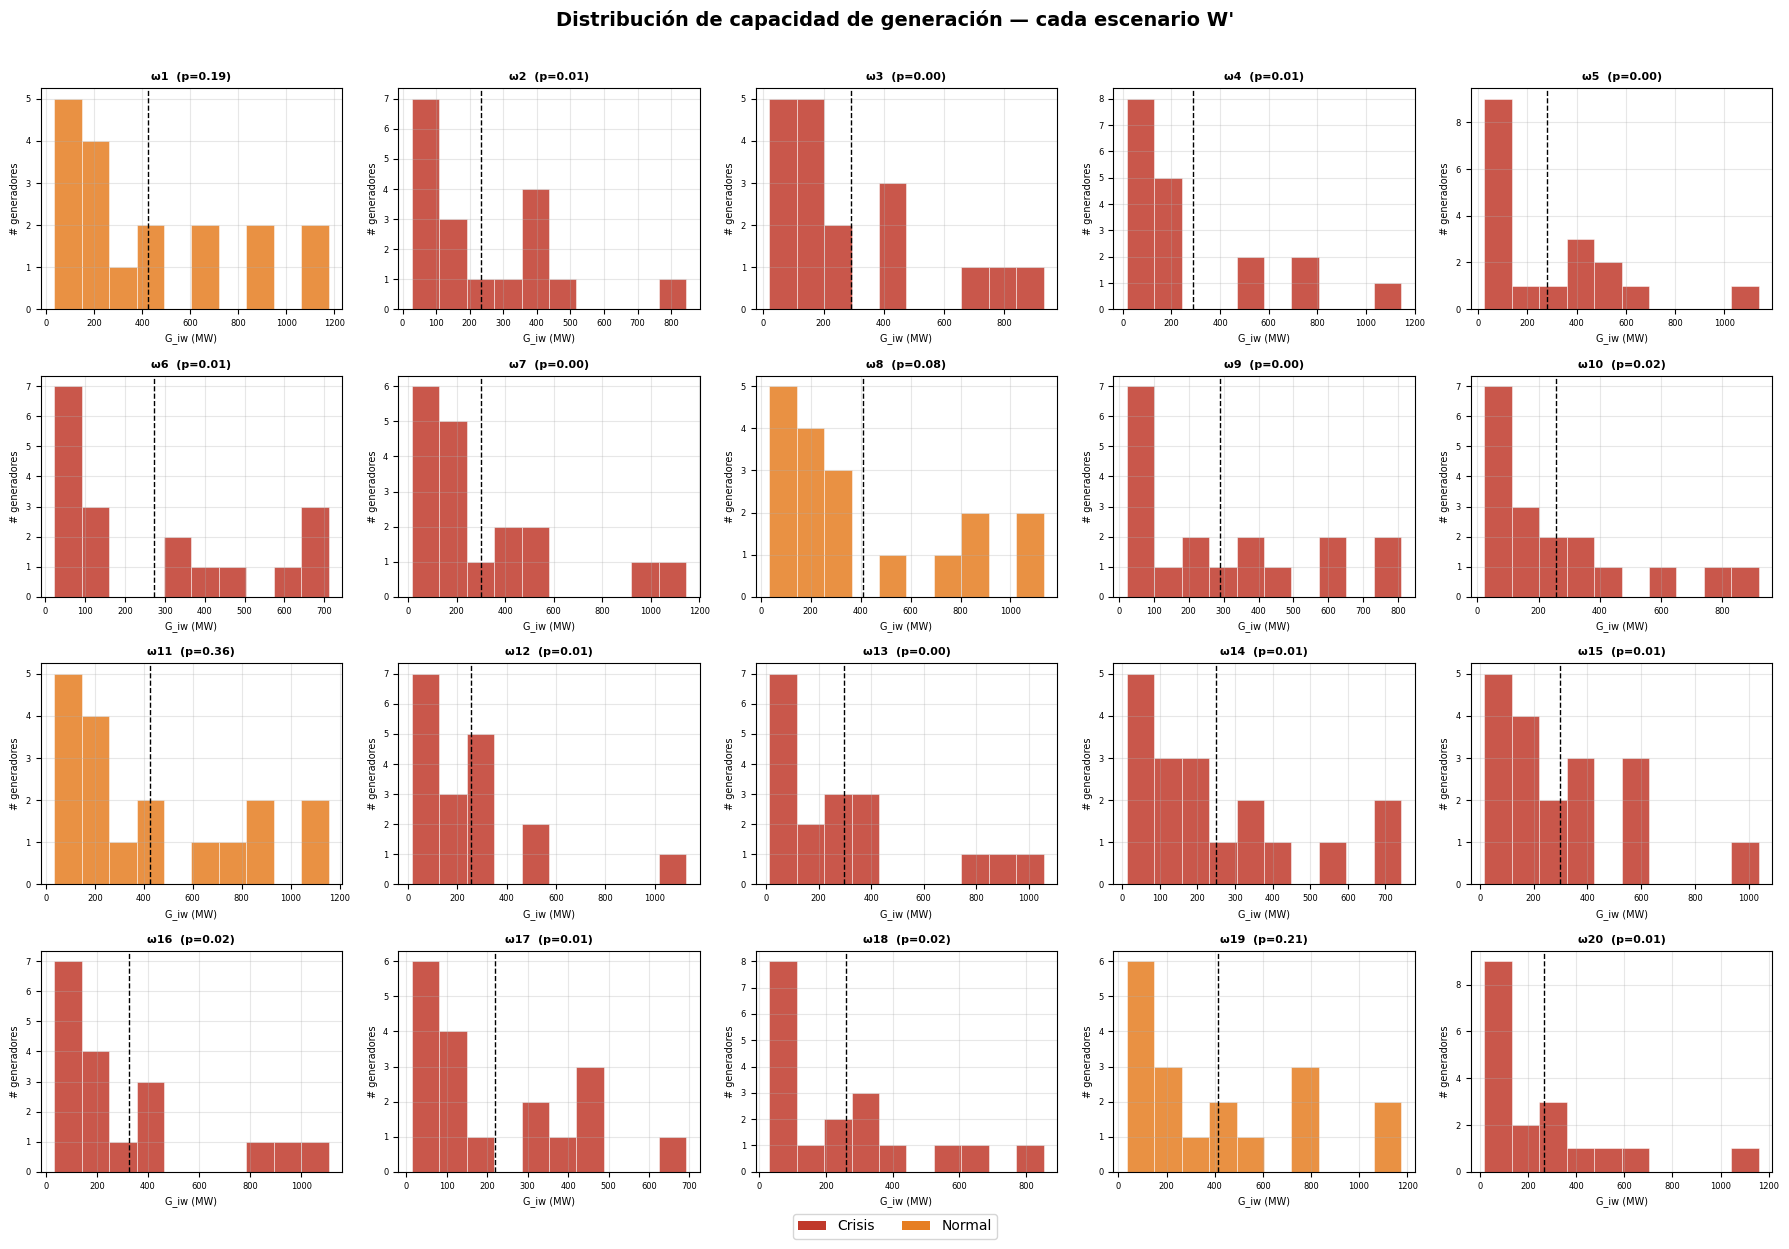

In [53]:
# Generación

fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

# solo nodos generadores
gen_nodes_list = nodes[nodes["is_generator"] == True]["node"].tolist()

for idx, w in enumerate(omegas_list):
    ax = axes[idx]
    # solo filas de generadores
    vals = dfG[(dfG["omega"] == w) & (dfG["node"].isin(gen_nodes_list))]["G_iw"].values
    crisis = dfp[dfp["omega"] == w]["crisis"].values[0]
    color  = "#c0392b" if crisis else "#e67e22"

    ax.hist(vals, bins=10, color=color, edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"ω{w}  (p={p_vals[idx]:.2f})", fontsize=8, fontweight="bold")
    ax.set_xlabel("G_iw (MW)", fontsize=7)
    ax.set_ylabel("# generadores", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.3)

fig.suptitle("Distribución de capacidad de generación — cada escenario W'",
             fontsize=14, fontweight="bold", y=1.01)
gen_legend = [Patch(facecolor="#c0392b", label="Crisis"),
              Patch(facecolor="#e67e22", label="Normal")]
fig.legend(handles=gen_legend, loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

Crisis scenarios tend to show lower and more dispersed generation levels, suggesting that some generators operate below their nominal capacity during disruptions. Normal scenarios remain more concentrated, indicating a more stable and reliable generation supply.

## Parameters

Let:

- $N$: set of nodes  
- $E$: set of arcs  
- $L \subseteq N$: set of demand nodes  
- $S \subseteq N$: set of generator nodes  
- $\Omega$: set of scenarios  

### Scenario-dependent parameters

- $D_{i\omega}$: demand at node $i$ under scenario $\omega$  
- $U_{e\omega}$: effective capacity of arc $e$ under scenario $\omega$  
- $c_{e\omega}$: operational cost of arc $e$ under scenario $\omega$  
- $G_{i\omega}$: available generation at generator node $i$ under scenario $\omega$  
- $p_\omega$: probability of scenario $\omega$  

### Network and investment parameters

- $U_e^{base}$: base capacity of arc $e$  
- $\Delta U_e$: capacity increase if arc $e$ is reinforced  
- $H_e$: reinforcement cost of arc $e$  
- $B$: total investment budget  
- $\pi$: penalty cost for unserved demand  
- $\alpha$: confidence level used in CVaR  
- $\lambda \in [0,1]$: weight assigned to risk in the mean-CVaR formulation

In [10]:
# Sets
omegas = dfp["omega"].tolist()
p_omega = dict(zip(dfp["omega"], dfp["p_omega"]))
nodes_list = dfD["node"].unique().tolist()
edges_list = dfU["e_id"].unique().tolist()
demand_nodes = dfD[dfD["D_iw"] > 0]["node"].unique().tolist()
gen_nodes = nodes[nodes["is_generator"] == True]["node"].tolist()

# Scenario-dependent parameters
D = {(r.omega, r.node): r.D_iw for _, r in dfD.iterrows()}
U_ew = {(r.omega, r.e_id): r.U_ew for _, r in dfU.iterrows()}
c_ew = {(r.omega, r.e_id): r.c_ew for _, r in dfc.iterrows()}
G_iw = {(r.omega, r.node): r.G_iw for _, r in dfG.iterrows()}

# Base network and investment parameters
U_base_dict = dict(zip(edges["e_id"], edges["U_base"]))
delta_U = 0.8
H_e = {e: 50.0 for e in edges_list} # costo de hardening
B = 2500.0 
pi = 190.0 
alpha = 0.95 

# Network topology
out_arcs = {i: edges[edges["i"] == i]["e_id"].tolist() for i in nodes_list}
in_arcs  = {i: edges[edges["j"] == i]["e_id"].tolist() for i in nodes_list}
arc_i = dict(zip(edges["e_id"], edges["i"]))
arc_j = dict(zip(edges["e_id"], edges["j"]))

print("W' cargado:", len(omegas), "escenarios")
print("Nodos:", len(nodes_list), "| Arcos:", len(edges_list))

W' cargado: 20 escenarios
Nodos: 118 | Arcos: 179


## Decision Variables

### First-stage decisions (investment)

$
h_e \in \{0,1\}
$

Binary variable indicating whether arc $e$ is reinforced.

### Second-stage decisions (operations)

For each scenario $\omega$:

Flow on arc:

$
f_{e\omega} \ge 0
$

Generation at generator node:

$
g_{i\omega} \ge 0
$

Unserved demand:

$
\delta_{i\omega} \ge 0
$

## Constraints

### 1. Budget constraint

$$
\sum_{e \in E} H_e h_e \le B
$$

This ensures that the total reinforcement cost does not exceed the available budget.

---

### 2. Flow balance constraints

#### Demand nodes

For each demand node $i \in L$ and scenario $\omega \in \Omega$:

$$
\sum_{e \in \delta^-(i)} f_{e\omega}
-
\sum_{e \in \delta^+(i)} f_{e\omega}
=
D_{i\omega} - \delta_{i\omega}
$$

#### Generator nodes

For each generator node $i \in S$ and scenario $\omega \in \Omega$:

$$
\sum_{e \in \delta^-(i)} f_{e\omega}
-
\sum_{e \in \delta^+(i)} f_{e\omega}
=
- g_{i\omega}
$$

#### Transit nodes

For each transit node $i \in N \setminus (L \cup S)$ and scenario $\omega \in \Omega$:

$$
\sum_{e \in \delta^-(i)} f_{e\omega}
-
\sum_{e \in \delta^+(i)} f_{e\omega}
=
0
$$

---

### 3. Demand shedding upper bound

For each demand node $i \in L$ and scenario $\omega \in \Omega$:

$$
\delta_{i\omega} \le D_{i\omega}
$$

This ensures that unserved demand cannot exceed total demand.

---

### 4. Generation upper bound

For each generator node $i \in S$ and scenario $\omega \in \Omega$:

$$
g_{i\omega} \le G_{i\omega}
$$

This ensures that generation does not exceed the available capacity at each generator node.

---

### 5. Arc capacity constraints

For each arc $e \in E$ and scenario $\omega \in \Omega$:

$$
f_{e\omega}
\le
U_{e\omega} (1 + \Delta U_e h_e)
$$

where $\beta$ represents the proportional capacity increase due to reinforcement.

---

### 6. CVaR auxiliary constraints

For each scenario $\omega \in \Omega$:

$$
s_\omega \ge L_\omega - \eta
$$

$$
s_\omega \ge 0
$$

where the operational loss in scenario $omega$ is:

$$
L_\omega =
\sum_{e \in E} c_{e\omega} f_{e\omega}
+
\pi \sum_{i \in L} \delta_{i\omega}
$$

## **Deterministic Model**

The deterministic model replaces uncertain parameters with their expected values across scenarios.

### Expected parameters

$$
\bar D_i = \sum_{\omega \in \Omega} p_\omega D_{i\omega}
$$

$$
\bar U_e = \sum_{\omega \in \Omega} p_\omega U_{e\omega}
$$

$$
\bar c_e = \sum_{\omega \in \Omega} p_\omega c_{e\omega}
$$

$$
\bar G_i = \sum_{\omega \in \Omega} p_\omega G_{i\omega}
$$

### Objective function

$$
\min
\sum_{e \in E} H_e h_e
+
\sum_{e \in E} \bar c_e f_e
+
\pi \sum_{i \in L} \delta_i
$$

### Interpretation

This model optimizes the network assuming average conditions.  
It is simple and computationally efficient, but it may underestimate the impact of uncertainty and extreme events.

In [11]:
def solve_deterministic(nodes_list, edges_list, demand_nodes, gen_nodes,
                        in_arcs, out_arcs, arc_i, arc_j,
                        U_base_dict, delta_U, H_e, B, pi,
                        D, U_ew, c_ew, G_iw, p_omega, omegas):
    # Calcular promedios ponderados
    D_mean  = {i: sum(p_omega[w] * D[(w, i)] for w in omegas) for i in demand_nodes}
    U_mean  = {e: sum(p_omega[w] * U_ew[(w, e)] for w in omegas) for e in edges_list}
    c_mean  = {e: sum(p_omega[w] * c_ew[(w, e)] for w in omegas) for e in edges_list}
    G_mean  = {i: sum(p_omega[w] * G_iw[(w, i)] for w in omegas) for i in gen_nodes}

    m = gp.Model("Deterministic")
    m.Params.OutputFlag = 0

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    f = m.addVars(edges_list, lb=0.0, name="f")
    delta_var = m.addVars(demand_nodes, lb=0.0, name="delta")
    g_var = m.addVars(gen_nodes, lb=0.0, name="g")

    m.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) +
        gp.quicksum(c_mean[e] * f[e] for e in edges_list) +
        pi * gp.quicksum(delta_var[i] for i in demand_nodes),
        GRB.MINIMIZE
    )

    m.addConstr(gp.quicksum(H_e[e] * h[e] for e in edges_list) <= B, "budget") #(1)

    # Balance de flujo
    for i in nodes_list:
        lhs = (gp.quicksum(f[e] for e in in_arcs.get(i, [])) -
               gp.quicksum(f[e] for e in out_arcs.get(i, []))) #(2.0)
        if i in demand_nodes:
            m.addConstr(lhs == D_mean[i] - delta_var[i], f"balance_{i}") #(2.1)
            m.addConstr(delta_var[i] <= D_mean[i], f"shed_ub_{i}") #(3)
        elif i in gen_nodes:
            m.addConstr(lhs == -g_var[i], f"balance_{i}") #(2.2)
            m.addConstr(g_var[i] <= G_mean[i], f"gen_ub_{i}") #(4)
        else:
            m.addConstr(lhs == 0, f"balance_{i}") #(2.3)

    # Capacidad con hardening
    for e in edges_list:
        cap= U_mean[e]*(1.0 + delta_U * h[e])  
        m.addConstr(f[e] <= cap, f"cap_{e}") #(5)

    m.optimize()

    if m.Status == GRB.OPTIMAL:
        h_sol = {e: round(h[e].X) for e in edges_list}
        obj   = m.ObjVal
        print(f"[Determinístico] Obj = {obj:,.2f} | Líneas reforzadas: {sum(h_sol.values())}")
        print("Líneas reforzadas:", [e for e in edges_list if h_sol[e] == 1])
        print(f"Demanda no servida total: {sum(delta_var[i].X for i in demand_nodes):,.2f}")
        print(f"costos faltantes: {pi * sum(delta_var[i].X for i in demand_nodes):,.2f}")
        print(f"Flujo total: {sum(f[e].X for e in edges_list):,.2f}")
        print(f"Costos operativos totales: {sum(c_mean[e] * f[e].X for e in edges_list):,.2f}")
        return h_sol, obj
    else:
        print("[Determinístico] No se encontró solución óptima")
        return None, None

h_det, obj_det = solve_deterministic(
    nodes_list, edges_list, demand_nodes, gen_nodes,
    in_arcs, out_arcs, arc_i, arc_j,
    U_base_dict, delta_U, H_e, B, pi,
    D, U_ew, c_ew, G_iw, p_omega, omegas
)

Set parameter Username
Set parameter LicenseID to value 2774763
Academic license - for non-commercial use only - expires 2027-02-03


[Determinístico] Obj = 270,203.27 | Líneas reforzadas: 8
Líneas reforzadas: [21, 22, 34, 58, 59, 63, 93, 94]
Demanda no servida total: 854.41
costos faltantes: 162,337.01
Flujo total: 8,044.12
Costos operativos totales: 107,466.26


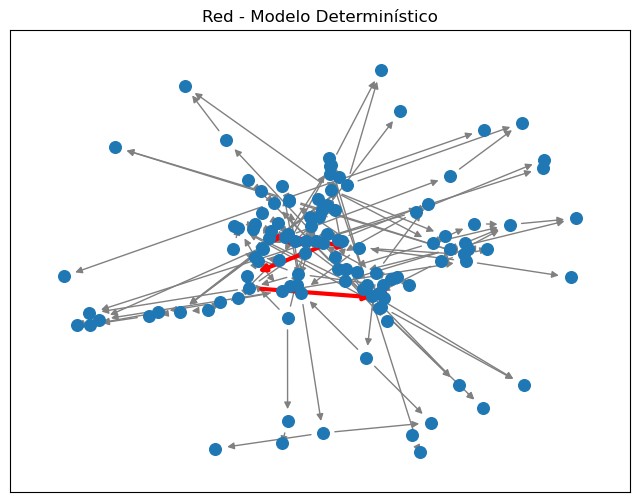

In [22]:
plot_network_with_hardening(nodes_list, edges_list, arc_i, arc_j, h_det, "Red - Modelo Determinístico")

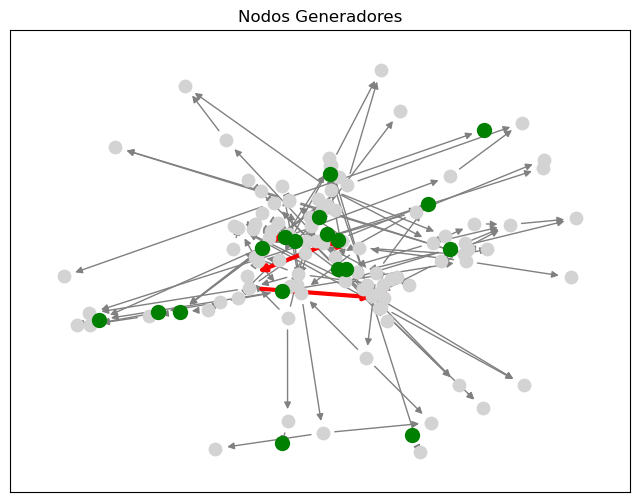

In [25]:
def generators(nodes_list, edges_list, arc_i, arc_j, h_solution, title, gen_nodes=None):
    G = nx.DiGraph()
    for n in nodes_list:
        G.add_node(n)
    for e in edges_list:
        i = arc_i[e]
        j = arc_j[e]
        G.add_edge(i, j)

    pos = nx.spring_layout(G, seed=42)

    reinforced = []
    normal = []
    for e in edges_list:
        i = arc_i[e]
        j = arc_j[e]
        if h_solution[e] > 0.5:
            reinforced.append((i, j))
        else:
            normal.append((i, j))

    plt.figure(figsize=(8,6))

    non_gen = [n for n in nodes_list if gen_nodes is None or n not in gen_nodes]
    if non_gen:
        nx.draw_networkx_nodes(G, pos, nodelist=non_gen, node_color="lightgray", node_size=80)
    if gen_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=gen_nodes, node_color="green", node_size=100)

    nx.draw_networkx_edges(G, pos, edgelist=normal, edge_color="gray", arrows=True)
    nx.draw_networkx_edges(G, pos, edgelist=reinforced, edge_color="red", width=3, arrows=True)

    plt.title(title)
    plt.show()

generators(nodes_list, edges_list, arc_i, arc_j, h_det, "Nodos Generadores", gen_nodes=gen_nodes)

## **Risk-Neutral Stochastic Model**

The stochastic model explicitly considers all scenarios and minimizes the expected operational cost.

### Scenario loss

For each scenario $\omega \in \Omega$:

$$
L_\omega =
\sum_{e \in E} c_{e\omega} f_{e\omega}
+
\pi \sum_{i \in L} \delta_{i\omega}
$$

### Objective function

$$
\min
\sum_{e \in E} H_e h_e
+
\sum_{\omega \in \Omega} p_\omega L_\omega
$$

### Interpretation

This model accounts for uncertainty explicitly and minimizes the expected total cost across scenarios.  
However, it remains **risk-neutral**, since it focuses on average performance and does not explicitly protect against extreme losses.

In [16]:
def solve_stochastic(nodes_list, edges_list, demand_nodes, gen_nodes,
                     in_arcs, out_arcs, arc_i, arc_j,
                     U_base_dict, delta_U, H_e, B, pi,
                     D, U_ew, c_ew, G_iw, p_omega, omegas):
    m = gp.Model("Stochastic")
    m.Params.OutputFlag = 0

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    f = m.addVars(edges_list, omegas, lb=0.0, name="f")
    delta_var = m.addVars(demand_nodes, omegas, lb=0.0, name="delta")
    g_var = m.addVars(gen_nodes, omegas, lb=0.0, name="g")

    L = {w: (gp.quicksum(c_ew[(w, e)] * f[e, w] for e in edges_list) +
             pi * gp.quicksum(delta_var[i, w] for i in demand_nodes))
         for w in omegas}

    m.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) +
        gp.quicksum(p_omega[w] * L[w] for w in omegas),
        GRB.MINIMIZE
    )

    m.addConstr(gp.quicksum(H_e[e] * h[e] for e in edges_list) <= B, "budget") #(1)

    for w in omegas:
        for i in nodes_list:
            lhs = (gp.quicksum(f[e, w] for e in in_arcs.get(i, [])) -
                   gp.quicksum(f[e, w] for e in out_arcs.get(i, []))) #(2.0)
            if i in demand_nodes:
                m.addConstr(lhs == D[(w, i)] - delta_var[i, w], f"bal_{i}_{w}") #(2.1)
                m.addConstr(delta_var[i, w] <= D[(w, i)], f"shed_ub_{i}_{w}") #(3)
            elif i in gen_nodes:
                m.addConstr(lhs == -g_var[i, w], f"bal_{i}_{w}") #(2.2)
                m.addConstr(g_var[i, w] <= G_iw[(w, i)], f"gen_ub_{i}_{w}") #(4)
            else:
                m.addConstr(lhs == 0, f"bal_{i}_{w}") #(2.3)

        for e in edges_list:
            cap = U_ew[(w, e)] * (1 + delta_U* h[e])
            m.addConstr(f[e, w] <= cap, f"cap_{e}_{w}") #(5)

    m.optimize()

    if m.Status == GRB.OPTIMAL:
        h_sol = {e: round(h[e].X) for e in edges_list}
        obj   = m.ObjVal
        print(f"[Estocástico] Obj = {obj:,.2f} | Líneas reforzadas: {sum(h_sol.values())}")
        print("Líneas reforzadas:", [e for e in edges_list if h_sol[e] == 1])
        print(f"Demanda no servida total: {sum(delta_var[i, w].X for i in demand_nodes for w in omegas):,.2f}")
        print(f"costos faltantes: {pi * sum(delta_var[i, w].X*p_omega[w] for i in demand_nodes for w in omegas):,.2f}")
        print(f"Flujo total: {sum(f[e, w].X for e in edges_list for w in omegas):,.2f}")
        print(f"Costos operativos totales: {sum(c_ew[(w, e)] * f[e, w].X*p_omega[w] for e in edges_list for w in omegas):,.2f}")
        return h_sol, obj
    else:
        print("[Estocástico] No se encontró solución óptima")
        return None, None

h_sto, obj_sto = solve_stochastic(
    nodes_list, edges_list, demand_nodes, gen_nodes,
    in_arcs, out_arcs, arc_i, arc_j,
    U_base_dict, delta_U, H_e, B, pi,
    D, U_ew, c_ew, G_iw, p_omega, omegas
)

[Estocástico] Obj = 339,484.74 | Líneas reforzadas: 19
Líneas reforzadas: [15, 17, 21, 22, 30, 34, 41, 48, 58, 59, 63, 93, 94, 106, 122, 124, 156, 159, 177]
Demanda no servida total: 91,683.13
costos faltantes: 250,538.34
Flujo total: 73,445.75
Costos operativos totales: 87,996.40


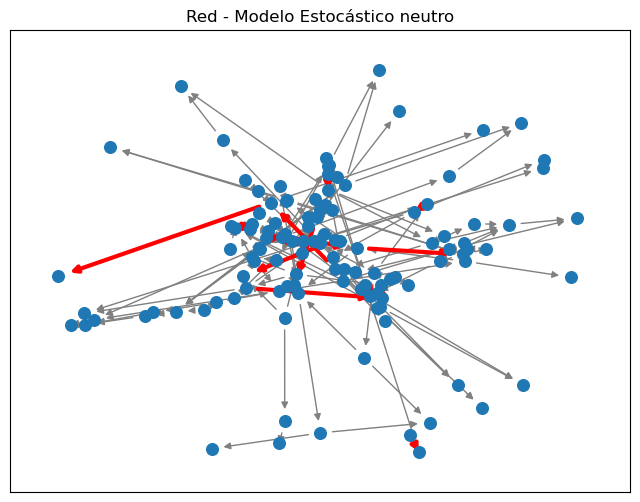

In [61]:
plot_network_with_hardening(nodes_list, edges_list, arc_i, arc_j, h_sto, "Red - Modelo Estocástico neutro")

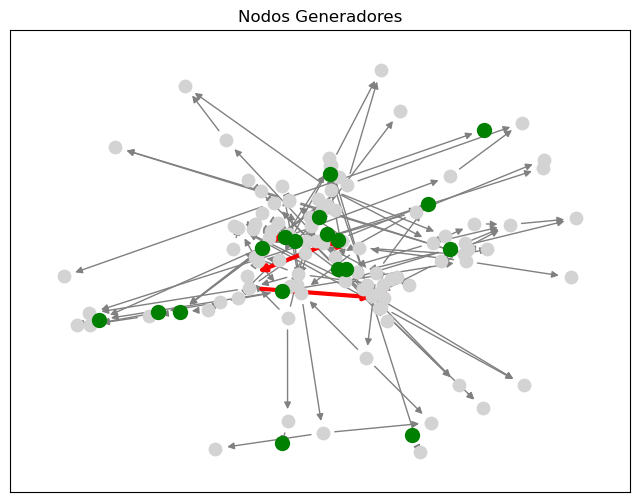

In [26]:
generators(nodes_list, edges_list, arc_i, arc_j, h_det, "Nodos Generadores", gen_nodes=gen_nodes)

## **Mean-CVaR Model**

This formulation combines expected cost and CVaR through a trade-off parameter $\lambda$.

### Scenario loss

$$
L_\omega =
\sum_{e \in E} c_{e\omega} f_{e\omega}
+
\pi \sum_{i \in L} \delta_{i\omega}
$$

### Expected cost

$$
\mathbb{E}[L] =
\sum_{\omega \in \Omega} p_\omega L_\omega
$$

### CVaR expression

$$
CVaR_\alpha =
\eta +
\frac{1}{1-\alpha}
\sum_{\omega \in \Omega} p_\omega s_\omega
$$

subject to:

$$
s_\omega \ge L_\omega - \eta
\qquad \forall \omega \in \Omega
$$

$$
s_\omega \ge 0
\qquad \forall \omega \in \Omega
$$

### Objective function

$$
\min
\sum_{e \in E} H_e h_e
+
(1-\lambda)\sum_{\omega \in \Omega} p_\omega L_\omega
+
\left(
\eta +
\frac{1}{1-\alpha}
\sum_{\omega \in \Omega} p_\omega s_\omega
\right)
$$

### Interpretation

This formulation balances:

- **expected operational performance**, and
- **protection against extreme losses**.

The parameter $\lambda$ controls the relative weight assigned to expected cost versus risk.  
When $\lambda$ increases, the model becomes more risk-averse.

In [28]:
def solve_cvar(nodes_list, edges_list, demand_nodes, gen_nodes,
               in_arcs, out_arcs, arc_i, arc_j,
               U_base_dict, delta_U, H_e, B, pi,
               D, U_ew, c_ew, G_iw, p_omega, omegas,
               alpha=0.95, lam=0.5):
    m = gp.Model("CVaR")
    m.Params.OutputFlag = 0

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    f = m.addVars(edges_list, omegas, lb=0.0, name="f")
    delta_var = m.addVars(demand_nodes, omegas, lb=0.0, name="delta")
    g_var = m.addVars(gen_nodes, omegas, lb=0.0, name="g")
    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    s   = m.addVars(omegas, lb=0.0, name="s")

    L = {w: (gp.quicksum(c_ew[(w, e)] * f[e, w] for e in edges_list) +
             pi * gp.quicksum(delta_var[i, w] for i in demand_nodes))
         for w in omegas}

    cvar_expr = eta + (1.0 / (1.0 - alpha)) * gp.quicksum(p_omega[w] * s[w] for w in omegas)
    exp_cost  = gp.quicksum(p_omega[w] * L[w] for w in omegas)
    invest    = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    m.setObjective(
        invest + (1 - lam) * exp_cost + cvar_expr,
        GRB.MINIMIZE
    )

    m.addConstr(gp.quicksum(H_e[e] * h[e] for e in edges_list) <= B, "budget") #(1)

    for w in omegas:
        m.addConstr(s[w] >= L[w] - eta, f"cvar_s_{w}") #(6)

        for i in nodes_list:
            lhs = (gp.quicksum(f[e, w] for e in in_arcs.get(i, [])) -
                   gp.quicksum(f[e, w] for e in out_arcs.get(i, []))) #(2.0)
            if i in demand_nodes:
                m.addConstr(lhs == D[(w, i)] - delta_var[i, w], f"bal_{i}_{w}") #(2.1)
                m.addConstr(delta_var[i, w] <= D[(w, i)], f"shed_ub_{i}_{w}") #(3)
            elif i in gen_nodes:
                m.addConstr(lhs == -g_var[i, w], f"bal_{i}_{w}") #(2.2)
                m.addConstr(g_var[i, w] <= G_iw[(w, i)], f"gen_ub_{i}_{w}") #(4)
            else:
                m.addConstr(lhs == 0, f"bal_{i}_{w}") #(2.3)

        for e in edges_list:
            cap = U_ew[(w, e)] * (1 + delta_U* h[e])
            m.addConstr(f[e, w] <= cap, f"cap_{e}_{w}") #(5)

    m.optimize()

    if m.Status == GRB.OPTIMAL:
        h_sol = {e: round(h[e].X) for e in edges_list}
        obj = m.ObjVal

        # -------------------------
        # Descomposición del objetivo
        # -------------------------
        invest_cost = sum(H_e[e] * h[e].X for e in edges_list)

        expected_unserved = sum(
            p_omega[w] * sum(delta_var[i, w].X for i in demand_nodes)
            for w in omegas
        )

        expected_shed_cost = sum(
            p_omega[w] * pi * sum(delta_var[i, w].X for i in demand_nodes)
            for w in omegas
        )

        expected_oper_cost = sum(
            p_omega[w] * sum(c_ew[(w, e)] * f[e, w].X for e in edges_list)
            for w in omegas
        )

        expected_total_loss = sum(
            p_omega[w] * (
                sum(c_ew[(w, e)] * f[e, w].X for e in edges_list)
                + pi * sum(delta_var[i, w].X for i in demand_nodes)
            )
            for w in omegas
        )

        eta_val = eta.X

        tail_term = (1.0 / (1.0 - alpha)) * sum(
            p_omega[w] * s[w].X for w in omegas
        )

        cvar_value = eta_val + tail_term

        expected_flow = sum(
            p_omega[w] * sum(f[e, w].X for e in edges_list)
            for w in omegas
        )

        # -------------------------
        # Prints clave
        # -------------------------
        print(f"[CVaR alpha={alpha}] Obj = {obj:,.2f}")
        print(f"Reinforced arcs: {sum(h_sol.values())}")
        print(f"Reinforced arc IDs: {[e for e in edges_list if h_sol[e] == 1]}")

        print("\n--- Objective decomposition ---")
        print(f"Investment cost: {invest_cost:,.2f}")
        print(f"eta: {eta_val:,.2f}")
        print(f"Tail term: {tail_term:,.2f}")
        print(f"CVaR value: {cvar_value:,.2f}")
        print(f"Investment + CVaR: {invest_cost + cvar_value:,.2f}")
        expected_component = (1.0 - lam) * expected_total_loss

        print(f"(1-lam) * E[L]: {expected_component:,.2f}")
        print(f"Investment + (1-lam)E[L] + CVaR: {invest_cost + expected_component + cvar_value:,.2f}")

        print("\n--- Expected operating metrics ---")
        print(f"Expected unserved demand: {expected_unserved:,.2f}")
        print(f"Expected shedding cost: {expected_shed_cost:,.2f}")
        print(f"Expected operating cost: {expected_oper_cost:,.2f}")
        print(f"Expected total loss E[L]: {expected_total_loss:,.2f}")
        print(f"Expected total flow: {expected_flow:,.2f}")

        print("\n--- Gap between expected loss and CVaR ---")
        print(f"CVaR - E[L]: {cvar_value - expected_total_loss:,.2f}")
        return h_sol, obj
    else:
        print("[CVaR] No se encontró solución óptima")
        return None, None

h_cvar, obj_cvar = solve_cvar(
    nodes_list, edges_list, demand_nodes, gen_nodes,
    in_arcs, out_arcs, arc_i, arc_j,
    U_base_dict, delta_U, H_e, B, pi,
    D, U_ew, c_ew, G_iw, p_omega, omegas,
    alpha=alpha, lam=0.5
)

[CVaR alpha=0.95] Obj = 1,447,887.79
Reinforced arcs: 14
Reinforced arc IDs: [15, 17, 21, 22, 30, 34, 48, 58, 59, 63, 93, 94, 122, 177]

--- Objective decomposition ---
Investment cost: 700.00
eta: 1,025,952.37
Tail term: 251,802.81
CVaR value: 1,277,755.17
Investment + CVaR: 1,278,455.17
(1-lam) * E[L]: 169,432.62
Investment + (1-lam)E[L] + CVaR: 1,447,887.79

--- Expected operating metrics ---
Expected unserved demand: 1,320.33
Expected shedding cost: 250,862.37
Expected operating cost: 88,002.86
Expected total loss E[L]: 338,865.23
Expected total flow: 6,584.10

--- Gap between expected loss and CVaR ---
CVaR - E[L]: 938,889.94


Under the optimized network, the expected operational loss is approximately 338,865, composed mainly of the cost of unserved demand (about 250,862) and a smaller portion of operating costs (around 88,003).

The VaR threshold $\eta$ at the 95% level is about 1,025,952, and the CVaR reaches 1,277,755, indicating that the **average loss** in the worst 5% of scenarios **is substantially higher** than the expected cost. 

The large gap between the expected loss and the CVaR (approximately 938,890) highlights the **presence of severe tail events in the system**. Consequently, the optimization prioritizes reducing extreme losses rather than only minimizing average operating cost, leading to a more resilient network design under high-impact uncertainty.

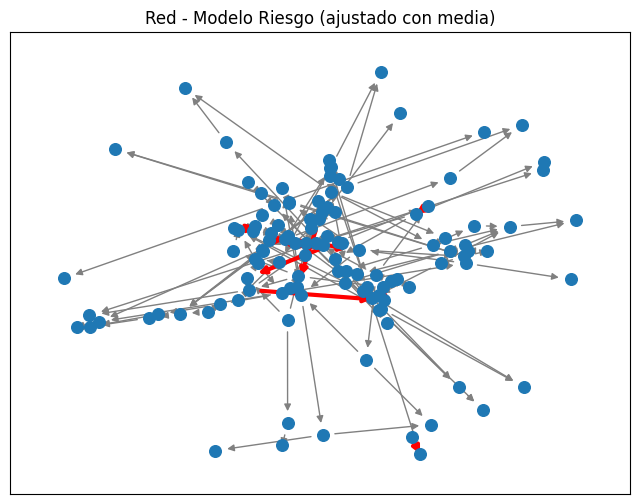

In [25]:
plot_network_with_hardening(nodes_list, edges_list, arc_i, arc_j, h_cvar, "Red - Modelo Riesgo (ajustado con media)")

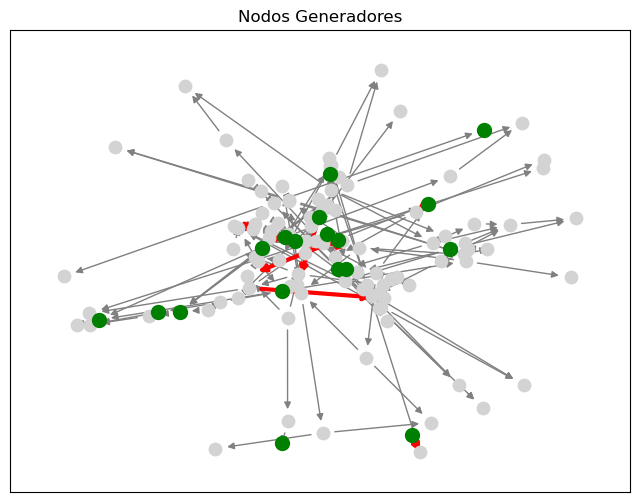

In [29]:
generators(nodes_list, edges_list, arc_i, arc_j, h_cvar, "Nodos Generadores", gen_nodes=gen_nodes)

## **Pure CVaR Model**

This formulation is fully risk-averse and minimizes the tail risk directly.

### Scenario loss

$$
L_\omega =
\sum_{e \in E} c_{e\omega} f_{e\omega}
+
\pi \sum_{i \in L} \delta_{i\omega}
$$

### CVaR expression

$$
CVaR_\alpha =
\eta +
\frac{1}{1-\alpha}
\sum_{\omega \in \Omega} p_\omega s_\omega
$$

subject to:

$$
s_\omega \ge L_\omega - \eta
\qquad \forall \omega \in \Omega
$$

$$
s_\omega \ge 0
\qquad \forall \omega \in \Omega
$$

### Objective function

$$
\min
\sum_{e \in E} H_e h_e
+
\eta +
\frac{1}{1-\alpha}
\sum_{\omega \in \Omega} p_\omega s_\omega
$$

### Interpretation

This model does not optimize the average operational cost directly.  
Instead, it focuses entirely on minimizing **extreme losses**, making it the most conservative and risk-averse formulation among the models considered.

In [30]:
def solve_cvar_pure(nodes_list, edges_list, demand_nodes, gen_nodes,
                    in_arcs, out_arcs, arc_i, arc_j,
                    U_base_dict, delta_U, H_e, B, pi,
                    D, U_ew, c_ew, G_iw, p_omega, omegas,
                    alpha=0.95):
    m = gp.Model("CVaR_pure")
    m.Params.OutputFlag = 0

    # Variables
    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    f = m.addVars(edges_list, omegas, lb=0.0, name="f")
    delta_var = m.addVars(demand_nodes, omegas, lb=0.0, name="delta")
    g_var = m.addVars(gen_nodes, omegas, lb=0.0, name="g")
    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    s = m.addVars(omegas, lb=0.0, name="s")

    # Pérdida operativa por escenario
    L = {
        w: gp.quicksum(c_ew[(w, e)] * f[e, w] for e in edges_list)
           + pi * gp.quicksum(delta_var[i, w] for i in demand_nodes)
        for w in omegas
    }

    # Inversión
    invest = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    # CVaR puro
    cvar_expr = eta + (1.0 / (1.0 - alpha)) * gp.quicksum(p_omega[w] * s[w] for w in omegas)

    # Función objetivo
    m.setObjective(
        invest + cvar_expr,
        GRB.MINIMIZE
    )

    # Presupuesto
    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= B,
        "budget"
    ) #(1)

    # Restricciones por escenario
    for w in omegas:

        # Definición de CVaR
        m.addConstr(s[w] >= L[w] - eta, f"cvar_s_{w}") #(6)

        # Balance nodal
        for i in nodes_list:
            lhs = (
                gp.quicksum(f[e, w] for e in in_arcs.get(i, []))
                - gp.quicksum(f[e, w] for e in out_arcs.get(i, []))
            ) #(2.0)
 
            if i in demand_nodes:
                m.addConstr(lhs == D[(w, i)] - delta_var[i, w], f"bal_{i}_{w}") #(2.1)
                m.addConstr(delta_var[i, w] <= D[(w, i)], f"shed_ub_{i}_{w}") #(3)

            elif i in gen_nodes:
                m.addConstr(lhs == -g_var[i, w], f"bal_{i}_{w}") #(2.2)
                m.addConstr(g_var[i, w] <= G_iw[(w, i)], f"gen_ub_{i}_{w}") #(4)

            else:
                m.addConstr(lhs == 0, f"bal_{i}_{w}") #(2.3)

        # Capacidad de arcos con hardening
        for e in edges_list:
            cap = U_ew[(w, e)] * (1 + delta_U* h[e])
            m.addConstr(f[e, w] <= cap, f"cap_{e}_{w}") #(5)

    m.optimize()

    if m.Status == GRB.OPTIMAL:
        h_sol = {e: round(h[e].X) for e in edges_list}
        obj = m.ObjVal

        # -------------------------
        # Objective decomposition
        # -------------------------
        invest_cost = sum(H_e[e] * h[e].X for e in edges_list)

        eta_val = eta.X

        tail_term = (1.0 / (1.0 - alpha)) * sum(
            p_omega[w] * s[w].X for w in omegas
        )

        cvar_val = eta_val + tail_term

        # -------------------------
        # Expected operating metrics
        # -------------------------
        expected_unserved = sum(
            p_omega[w] * sum(delta_var[i, w].X for i in demand_nodes)
            for w in omegas
        )

        expected_shed_cost = pi * expected_unserved

        expected_oper_cost = sum(
            p_omega[w] * sum(c_ew[(w, e)] * f[e, w].X for e in edges_list)
            for w in omegas
        )

        expected_total_loss = expected_shed_cost + expected_oper_cost

        expected_flow = sum(
            p_omega[w] * sum(f[e, w].X for e in edges_list)
            for w in omegas
        )

        # -------------------------
        # Prints
        # -------------------------
        print(f"[CVaR PURE alpha={alpha}] Obj = {obj:,.2f}")
        print(f"Reinforced arcs: {sum(h_sol.values())}")
        print("Reinforced arc IDs:", [e for e in edges_list if h_sol[e] == 1])

        print("\n--- Objective decomposition ---")
        print(f"Investment cost: {invest_cost:,.2f}")
        print(f"eta (VaR approx): {eta_val:,.2f}")
        print(f"Tail term: {tail_term:,.2f}")
        print(f"CVaR value: {cvar_val:,.2f}")
        print(f"Investment + CVaR: {invest_cost + cvar_val:,.2f}")

        print("\n--- Expected operating metrics ---")
        print(f"Expected unserved demand: {expected_unserved:,.2f}")
        print(f"Expected shedding cost: {expected_shed_cost:,.2f}")
        print(f"Expected operating cost: {expected_oper_cost:,.2f}")
        print(f"Expected total loss E[L]: {expected_total_loss:,.2f}")
        print(f"Expected total flow: {expected_flow:,.2f}")

        print("\n--- Risk gap ---")
        print(f"CVaR - E[L]: {cvar_val - expected_total_loss:,.2f}")


        return h_sol, obj
    else:
        print("[CVaR puro] No se encontró solución óptima")
        return None, None


h_cvar_pure, obj_cvar_pure = solve_cvar_pure(
    nodes_list, edges_list, demand_nodes, gen_nodes,
    in_arcs, out_arcs, arc_i, arc_j,
    U_base_dict, delta_U, H_e, B, pi,
    D, U_ew, c_ew, G_iw, p_omega, omegas,
    alpha=alpha
)

[CVaR PURE alpha=0.95] Obj = 1,277,755.17
Reinforced arcs: 0
Reinforced arc IDs: []

--- Objective decomposition ---
Investment cost: 0.00
eta (VaR approx): 1,025,952.37
Tail term: 251,802.81
CVaR value: 1,277,755.17
Investment + CVaR: 1,277,755.17

--- Expected operating metrics ---
Expected unserved demand: 2,366.93
Expected shedding cost: 449,717.65
Expected operating cost: 37,060.64
Expected total loss E[L]: 486,778.28
Expected total flow: 2,942.27

--- Risk gap ---
CVaR - E[L]: 790,976.89


The pure CVaR model chooses not to reinforce any arc, indicating that under the current formulation reinforcement is not effective enough to significantly reduce the worst-case tail losses.

Therefore, the pure CVaR formulation reveals a limitation of the current hardening design: it is not sufficient to mitigate the most severe tail events.

The pure CVaR model chooses not to reinforce any arc, indicating that under the current formulation reinforcement does not significantly reduce the worst tail losses. While reinforcement can improve performance in normal or moderately adverse scenarios, the most extreme scenarios in the model are likely dominated by severe capacity failures, high demand spikes, or multiple simultaneous disruptions. Because the pure CVaR objective focuses exclusively on the worst 5% of outcomes, investments that mainly improve moderate scenarios do not provide sufficient benefit. As a result, the model prefers not to invest and instead accepts higher expected unserved demand while targeting only the extreme tail risk.


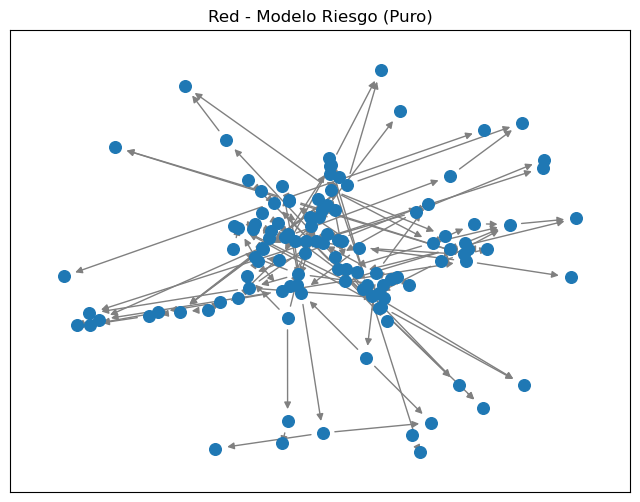

In [31]:
plot_network_with_hardening(nodes_list, edges_list, arc_i, arc_j, h_cvar_pure, "Red - Modelo Riesgo (Puro)")

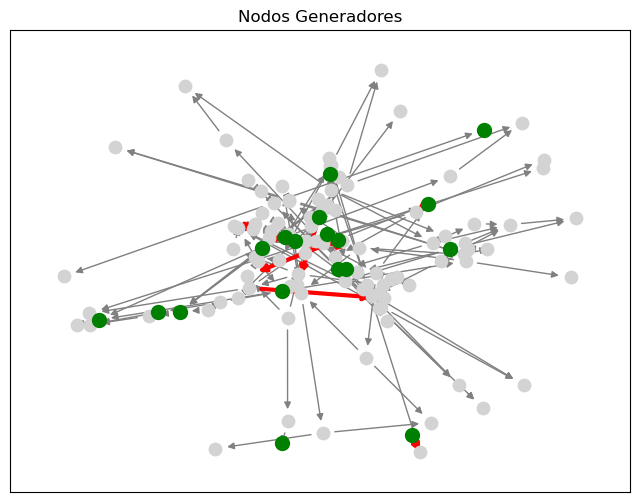

In [33]:
generators(nodes_list, edges_list, arc_i, arc_j, h_cvar, "Nodos Generadores", gen_nodes=gen_nodes)

# **Backtesting**

To evaluate the actual performance of the investment policies obtained by the different models, we performed a backtesting procedure. This process involves fixing the first-stage investment decisions (the reinforced arcs) and simulating the system's operation across a large, new set of scenarios that the model did not encounter during optimization.

This procedure provides an unbiased estimate of how each policy would behave in the "real world." Below, we analyze the total costs (investment + operation) for each model across the 100 test scenarios.

In [54]:
print("\nBacktesting y Evaluación de Modelos\n")
print("Iniciando backtesting sobre un conjunto común de escenarios de prueba...")

def backtest_on_scenarios_split(h_sol, test_scenarios, nodes_list, edges_list, demand_nodes, gen_nodes,
                                in_arcs, out_arcs, U_base_dict, delta_U, pi, nodes, edges):

    total_costs = []
    op_costs = []
    uns_costs = []
    invest_costs = []

    for sc in test_scenarios:

        U_sc = dict(zip(sc["U"]["e_id"], sc["U"]["U_w"]))
        c_sc = dict(zip(sc["c"]["e_id"], sc["c"]["c_w"]))
        D_sc = dict(zip(sc["D"]["node"], sc["D"]["D_w"]))
        G_sc = dict(zip(sc["G"]["node"], sc["G"]["G_w"]))

        m = gp.Model("backtest_op")
        m.Params.OutputFlag = 0

        f  = m.addVars(edges_list, lb=0.0, name="f")
        dv = m.addVars(demand_nodes, lb=0.0, name="delta")
        gv = m.addVars(gen_nodes, lb=0.0, name="g")

        m.setObjective(
            gp.quicksum(c_sc[e] * f[e] for e in edges_list) +
            pi * gp.quicksum(dv[i] for i in demand_nodes),
            GRB.MINIMIZE
        )

        for i in nodes_list:
            lhs = (gp.quicksum(f[e] for e in in_arcs.get(i, [])) -
                   gp.quicksum(f[e] for e in out_arcs.get(i, [])))

            if i in demand_nodes:
                d_i = D_sc.get(i, 0.0)
                m.addConstr(lhs == d_i - dv[i])
                m.addConstr(dv[i] <= d_i)

            elif i in gen_nodes:
                m.addConstr(lhs == -gv[i])
                m.addConstr(gv[i] <= G_sc.get(i, 0.0))

            else:
                m.addConstr(lhs == 0)

        for e in edges_list:
            cap = U_sc[e] * (1 + delta_U * h_sol.get(e, 0))
            m.addConstr(f[e] <= cap)

        m.optimize()

        if m.Status == GRB.OPTIMAL:

            # -------- COSTOS --------

            op_cost = sum(c_sc[e] * f[e].X for e in edges_list)

            uns_cost = pi * sum(dv[i].X for i in demand_nodes)

            invest_cost = sum(H_e[e] * h_sol.get(e, 0) for e in edges_list)

            total = op_cost + uns_cost + invest_cost

            op_costs.append(op_cost)
            uns_costs.append(uns_cost)
            invest_costs.append(invest_cost)
            total_costs.append(total)

        else:

            op_costs.append(np.nan)
            uns_costs.append(np.nan)
            invest_costs.append(np.nan)
            total_costs.append(np.nan)

    return {
        "total": np.array(total_costs),
        "operativo": np.array(op_costs),
        "no_servida": np.array(uns_costs),
        "inversion": np.array(invest_costs)
    }


# Parámetros del backtesting
N_TEST_SCENARIOS = 100  # Aumentamos el número para un análisis más robusto
BACKTEST_SEED = 123       # Semilla fija para reproducibilidad

print(f"Generando {N_TEST_SCENARIOS} escenarios de prueba con semilla {BACKTEST_SEED}...")

# Generamos los escenarios de prueba UNA SOLA VEZ
rng_test = np.random.default_rng(BACKTEST_SEED)
test_scenarios = []
for _ in range(N_TEST_SCENARIOS):
    sc = sample_one_scenario_W(nodes, edges, rng_test,
                               correlated_outage_nodes=gens)
    test_scenarios.append(sc)
print("Escenarios de prueba generados.")

# Ejecutamos el backtesting para cada modelo usando la MISMA lista de escenarios
print("\nEvaluando la política de cada modelo sobre los escenarios de prueba...")
bt_det  = backtest_on_scenarios_split(h_det,  test_scenarios, nodes_list, edges_list,
                                      demand_nodes, gen_nodes, in_arcs, out_arcs,
                                      U_base_dict, delta_U, pi, nodes, edges)

bt_sto  = backtest_on_scenarios_split(h_sto,  test_scenarios, nodes_list, edges_list,
                                      demand_nodes, gen_nodes, in_arcs, out_arcs,
                                      U_base_dict, delta_U, pi, nodes, edges)

bt_cvar = backtest_on_scenarios_split(h_cvar, test_scenarios, nodes_list, edges_list,
                                      demand_nodes, gen_nodes, in_arcs, out_arcs,
                                      U_base_dict, delta_U, pi, nodes, edges)

bt_cvar_pure = backtest_on_scenarios_split(h_cvar_pure, test_scenarios, nodes_list, edges_list,
                                      demand_nodes, gen_nodes, in_arcs, out_arcs,
                                      U_base_dict, delta_U, pi, nodes, edges)


Backtesting y Evaluación de Modelos

Iniciando backtesting sobre un conjunto común de escenarios de prueba...
Generando 100 escenarios de prueba con semilla 123...
Escenarios de prueba generados.

Evaluando la política de cada modelo sobre los escenarios de prueba...


Metricas y comparación

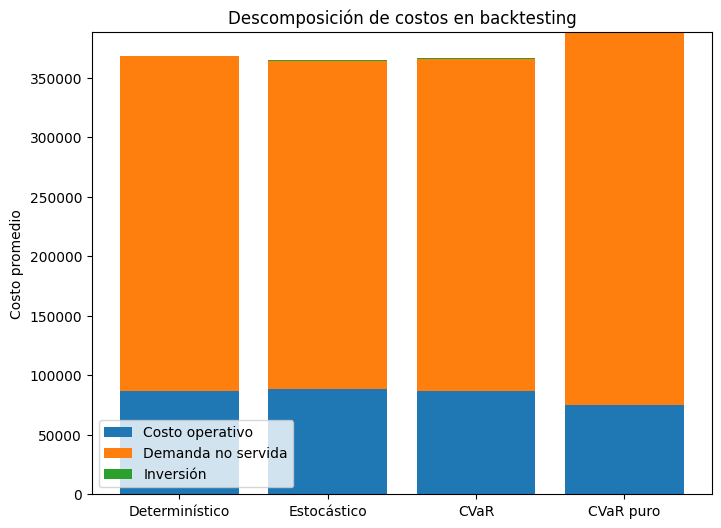

In [44]:
labels = ["Determinístico","Estocástico","CVaR", "CVaR puro"]

oper = [
    np.nanmean(bt_det["operativo"]),
    np.nanmean(bt_sto["operativo"]),
    np.nanmean(bt_cvar["operativo"]),
    np.nanmean(bt_cvar_pure["operativo"])
]

uns = [
    np.nanmean(bt_det["no_servida"]),
    np.nanmean(bt_sto["no_servida"]),
    np.nanmean(bt_cvar["no_servida"]),
    np.nanmean(bt_cvar_pure["no_servida"])
]

inv = [
    np.nanmean(bt_det["inversion"]),
    np.nanmean(bt_sto["inversion"]),
    np.nanmean(bt_cvar["inversion"]),
    np.nanmean(bt_cvar_pure["inversion"])
]

plt.figure(figsize=(8,6))

plt.bar(labels, oper, label="Costo operativo")
plt.bar(labels, uns, bottom=oper, label="Demanda no servida")

bottom2 = np.array(oper) + np.array(uns)

plt.bar(labels, inv, bottom=bottom2, label="Inversión")

plt.ylabel("Costo promedio")
plt.title("Descomposición de costos en backtesting")

plt.legend()
plt.show()

La descomposición de costos muestra que el componente más grande del costo total en todos los modelos es la penalización asociada con la demanda no atendida, la cual domina los costos operativos y de inversión. Los modelos determinista, estocástico y CVaR presentan estructuras de costos muy similares, lo que indica que sus decisiones de refuerzo logran un rendimiento operativo comparable.

In [55]:

def metricas(costos, nombre, alpha=0.95):
    costos = costos[~np.isnan(costos)]
    mean   = np.mean(costos)
    p90    = np.percentile(costos, 90)
    p95    = np.percentile(costos, 95)
    p99    = np.percentile(costos, 99)
    # CVaR empírico
    var    = np.percentile(costos, alpha * 100)
    cvar   = costos[costos >= var].mean()
    return {"Modelo": nombre, "E[Costo]": mean,
            "P90": p90, "P95": p95, "P99": p99, "CVaR_95": cvar}

rows_total = [
    metricas(bt_det["total"], "Determinístico"),
    metricas(bt_sto["total"], "Estocástico"),
    metricas(bt_cvar["total"], "CVaR"),
    metricas(bt_cvar_pure["total"], "CVaR puro")
]

df_total = pd.DataFrame(rows_total).set_index("Modelo")
print("\nCOSTO TOTAL")
print(df_total.to_string())


COSTO TOTAL
                     E[Costo]           P90           P95           P99       CVaR_95
Modelo                                                                               
Determinístico  368725.338785  1.083683e+06  1.239887e+06  1.385986e+06  1.356325e+06
Estocástico     365178.251267  1.084233e+06  1.240437e+06  1.386536e+06  1.356875e+06
CVaR            366470.576834  1.083983e+06  1.240187e+06  1.386286e+06  1.356625e+06
CVaR puro       388368.712797  1.100068e+06  1.239487e+06  1.385586e+06  1.355925e+06


In [56]:
rows_oper = [
    metricas(bt_det["operativo"], "Determinístico"),
    metricas(bt_sto["operativo"], "Estocástico"),
    metricas(bt_cvar["operativo"], "CVaR"),
    metricas(bt_cvar_pure["operativo"], "CVaR puro")
]

df_oper = pd.DataFrame(rows_oper).set_index("Modelo")
print("\nCOSTO OPERATIVO")
print(df_oper.to_string())


COSTO OPERATIVO
                    E[Costo]            P90            P95            P99        CVaR_95
Modelo                                                                                  
Determinístico  86502.720560  105462.487763  107293.231085  108329.730772  108350.097949
Estocástico     88345.468451  106359.322310  107799.912316  111322.817454  110644.907388
CVaR            86458.692169  105483.279419  107315.061337  108349.789355  108584.311214
CVaR puro       74829.693707   97688.953171   99459.981808  104114.260563  104477.922584


In [57]:
rows_uns = [
    metricas(bt_det["no_servida"], "Determinístico"),
    metricas(bt_sto["no_servida"], "Estocástico"),
    metricas(bt_cvar["no_servida"], "CVaR"),
    metricas(bt_cvar_pure["no_servida"], "CVaR puro")
]

df_uns = pd.DataFrame(rows_uns).set_index("Modelo")
print("\nDEMANDA NO SERVIDA")
print(df_uns.to_string())


DEMANDA NO SERVIDA
                     E[Costo]           P90           P95           P99       CVaR_95
Modelo                                                                               
Determinístico  281822.618224  1.083283e+06  1.239487e+06  1.385586e+06  1.355925e+06
Estocástico     275882.782817  1.083283e+06  1.239487e+06  1.385586e+06  1.355925e+06
CVaR            279311.884665  1.083283e+06  1.239487e+06  1.385586e+06  1.355925e+06
CVaR puro       313539.019090  1.083283e+06  1.239487e+06  1.385586e+06  1.355925e+06


In [58]:
rows_inv = [
    metricas(bt_det["inversion"], "Determinístico"),
    metricas(bt_sto["inversion"], "Estocástico"),
    metricas(bt_cvar["inversion"], "CVaR"),
    metricas(bt_cvar_pure["inversion"], "CVaR puro")
]

df_inv = pd.DataFrame(rows_inv).set_index("Modelo")
print("\nCOSTO DE INVERSIÓN")
print(df_inv.to_string())


COSTO DE INVERSIÓN
                E[Costo]    P90    P95    P99  CVaR_95
Modelo                                                
Determinístico     400.0  400.0  400.0  400.0    400.0
Estocástico        950.0  950.0  950.0  950.0    950.0
CVaR               700.0  700.0  700.0  700.0    700.0
CVaR puro            0.0    0.0    0.0    0.0      0.0


Gráficos

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7340\743707217.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


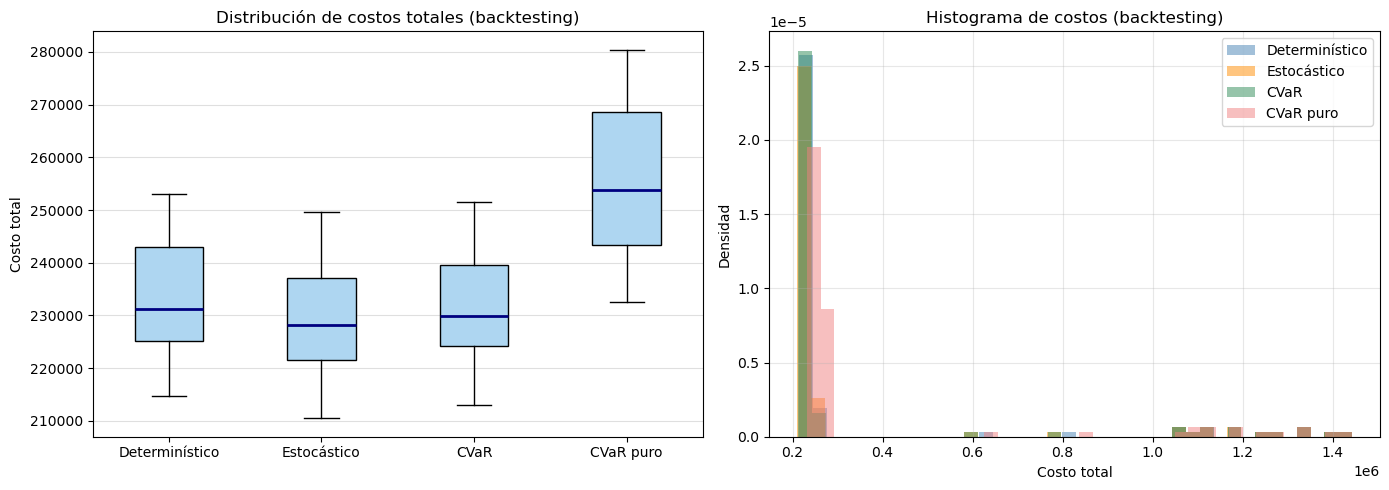

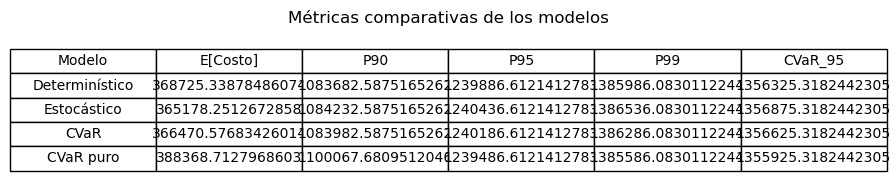

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------- Boxplot de costos --------
axes[0].boxplot(
    [
        bt_det["total"][~np.isnan(bt_det["total"])],
        bt_sto["total"][~np.isnan(bt_sto["total"])],
        bt_cvar["total"][~np.isnan(bt_cvar["total"])],
        bt_cvar_pure["total"][~np.isnan(bt_cvar_pure["total"])]
    ],
    labels=["Determinístico", "Estocástico", "CVaR", "CVaR puro"],
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="#AED6F1"),
    medianprops=dict(color="navy", linewidth=2)
)

axes[0].set_title("Distribución de costos totales (backtesting)")
axes[0].set_ylabel("Costo total")
axes[0].grid(axis="y", alpha=0.4)


# -------- Histograma superpuesto --------
for costos, label, color in [
    (bt_det["total"],  "Determinístico", "steelblue"),
    (bt_sto["total"],  "Estocástico", "darkorange"),
    (bt_cvar["total"], "CVaR", "seagreen"),
    (bt_cvar_pure["total"], "CVaR puro", "lightcoral"),
]:
    c = costos[~np.isnan(costos)]
    axes[1].hist(c, bins=40, alpha=0.5, label=label, color=color, density=True)

axes[1].set_title("Histograma de costos (backtesting)")
axes[1].set_xlabel("Costo total")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150)
plt.show()


# -------- Tabla de métricas --------
fig2, ax2 = plt.subplots(figsize=(9, 2))
ax2.axis("off")

tabla = df_total.reset_index()

t = ax2.table(
    cellText=tabla.values.tolist(),
    colLabels=tabla.columns.tolist(),
    cellLoc="center",
    loc="center"
)

t.auto_set_font_size(False)
t.set_fontsize(10)
t.scale(1.2, 1.6)

plt.title("Métricas comparativas de los modelos", pad=12)

plt.tight_layout()
plt.savefig("tabla_metricas.png", dpi=150)
plt.show()

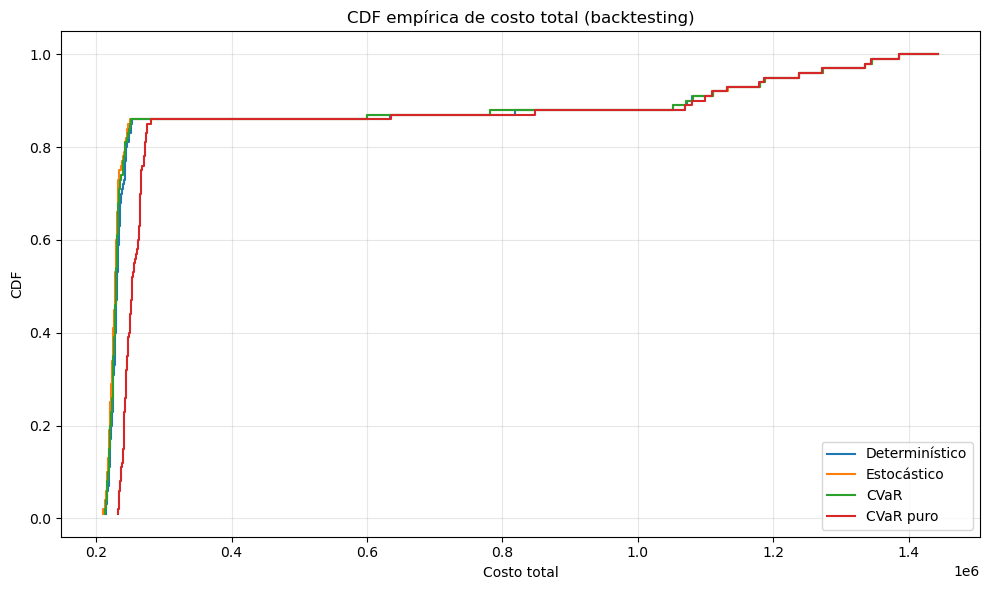

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7340\2213741084.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([bt["no_servida"][~np.isnan(bt["no_servida"])] for bt in bt_dicts],
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7340\2213741084.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([bt["operativo"][~np.isnan(bt["operativo"])] for bt in bt_dicts],


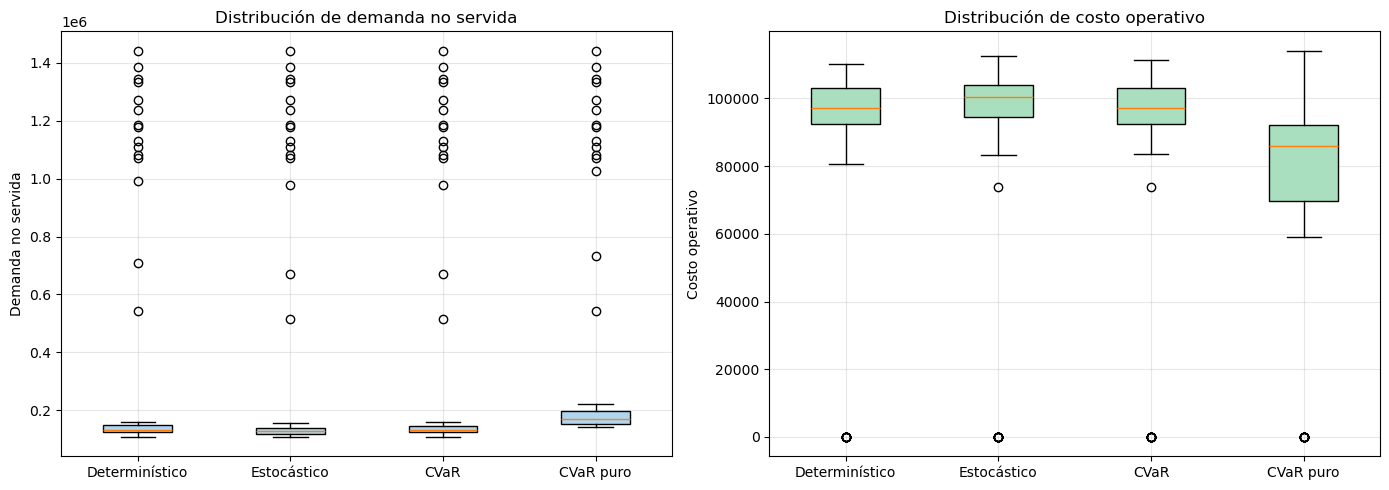

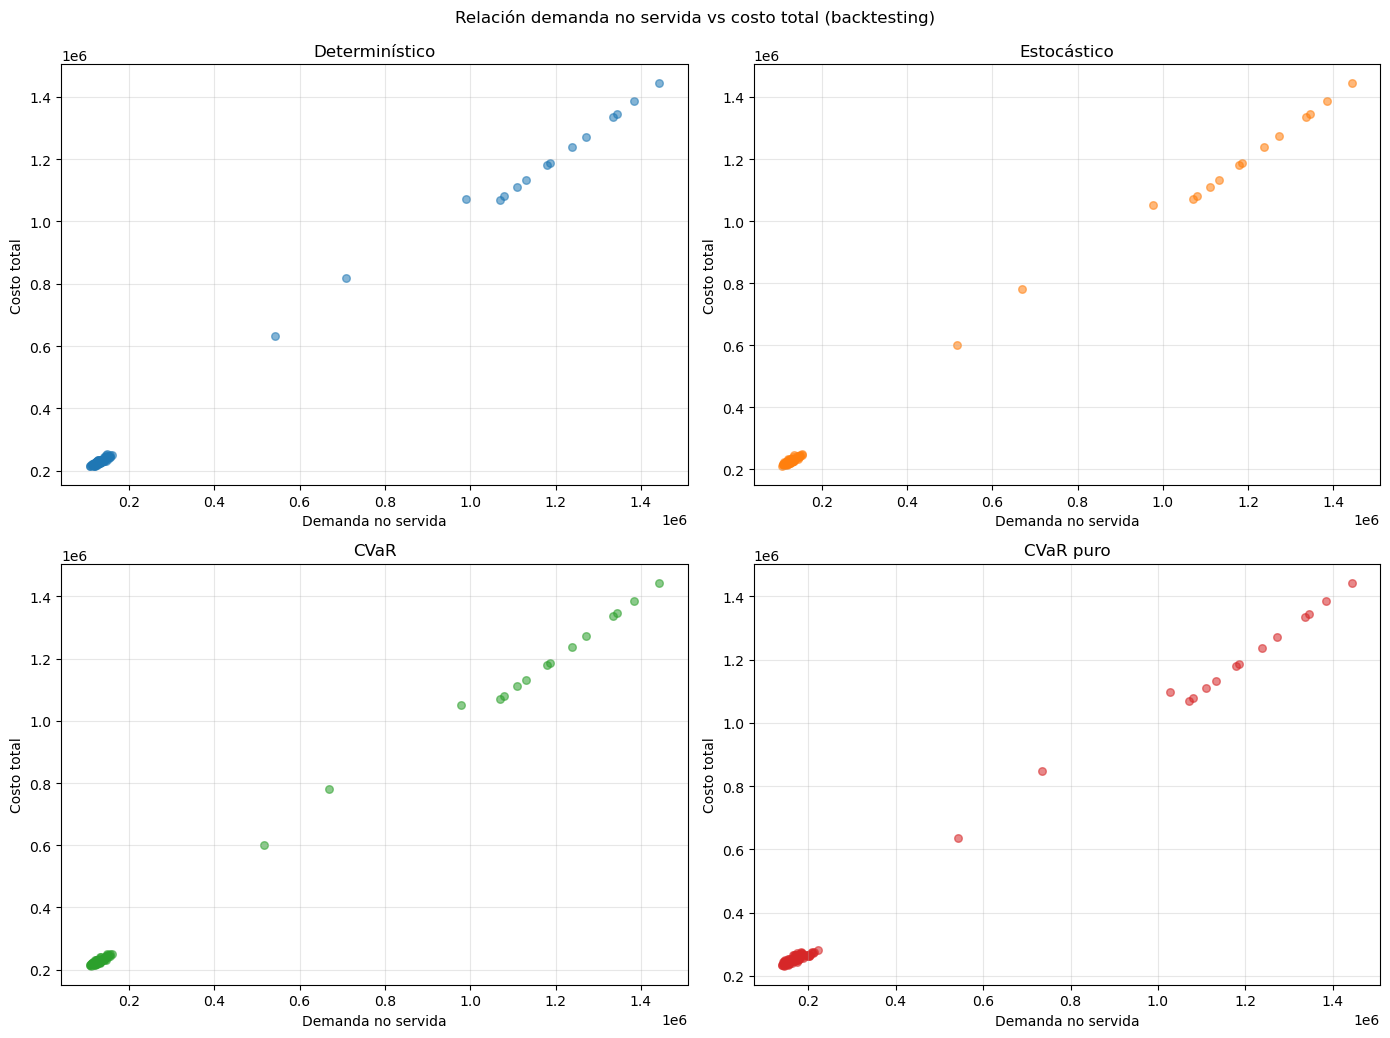

                E[Costo total]           P95           P99        CVaR95
Modelo                                                                  
Determinístico   368725.338785  1.239887e+06  1.385986e+06  1.356325e+06
Estocástico      365178.251267  1.240437e+06  1.386536e+06  1.356875e+06
CVaR             366470.576834  1.240187e+06  1.386286e+06  1.356625e+06
CVaR puro        388368.712797  1.239487e+06  1.385586e+06  1.355925e+06

Conclusión rápida:
 - Mejor P95: CVaR puro
 - Mejor P99: CVaR puro
 - Mejor CVaR95: CVaR puro
Modelos con mejor robustez de cola (menores costos en colas) tienen ventaja en escenarios adversos; los modelos CVaR suelen liderar en este criterio.


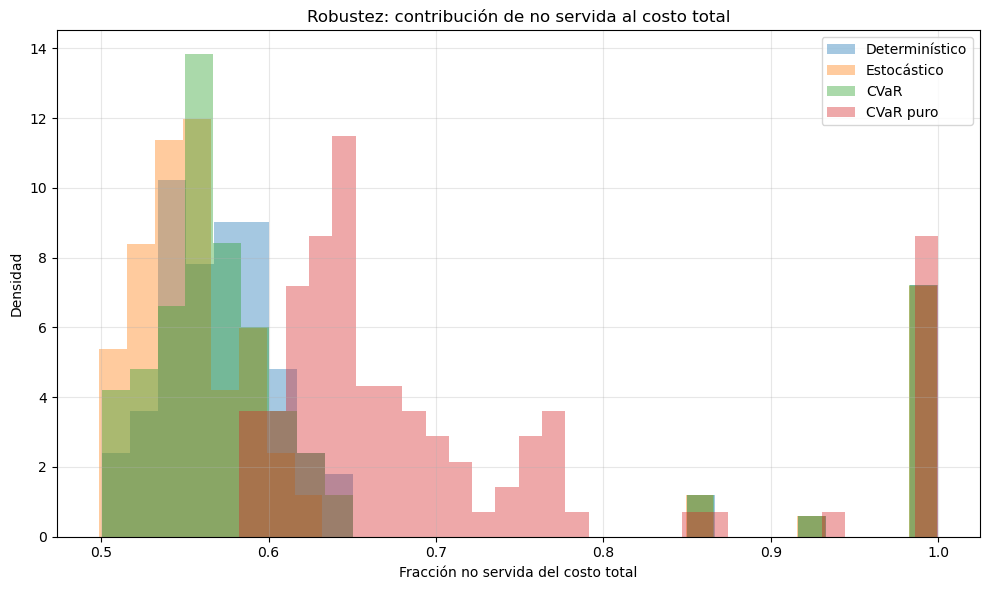

In [ ]:
model_names = ["Determinístico", "Estocástico", "CVaR", "CVaR puro"]
bt_dicts = [bt_det, bt_sto, bt_cvar, bt_cvar_pure]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# 1) 
plt.figure(figsize=(10, 6))
for name, bt, c in zip(model_names, bt_dicts, colors):
    costs = bt["total"][~np.isnan(bt["total"])]
    costs_sorted = np.sort(costs)
    cdf = np.arange(1, len(costs_sorted)+1) / len(costs_sorted)
    plt.step(costs_sorted, cdf, label=name, color=c)
plt.xlabel("Costo total")
plt.ylabel("CDF")
plt.title("CDF empírica de costo total (backtesting)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([bt["no_servida"][~np.isnan(bt["no_servida"])] for bt in bt_dicts],
                labels=model_names, patch_artist=True,
                boxprops=dict(facecolor="#AED6F1"))
axes[0].set_title("Distribución de demanda no servida")
axes[0].set_ylabel("Demanda no servida")
axes[0].grid(alpha=0.3)

axes[1].boxplot([bt["operativo"][~np.isnan(bt["operativo"])] for bt in bt_dicts],
                labels=model_names, patch_artist=True,
                boxprops=dict(facecolor="#A9DFBF"))
axes[1].set_title("Distribución de costo operativo")
axes[1].set_ylabel("Costo operativo")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3)
fig, axs = plt.subplots(2, 2, figsize=(14, 11), sharex=False, sharey=False)
axs = axs.flatten()
for ax, nm, bt, c in zip(axs, model_names, bt_dicts, colors):
    ax.scatter(bt["no_servida"], bt["total"], alpha=0.55, s=30, color=c)
    ax.set_title(f"{nm}")
    ax.set_xlabel("Demanda no servida")
    ax.set_ylabel("Costo total")
    ax.grid(alpha=0.3)
plt.suptitle("Relación demanda no servida vs costo total (backtesting)", y=0.94)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 4) 
def tail_metrics(arr, alpha=0.95):
    arr = arr[~np.isnan(arr)]
    p95 = np.percentile(arr, 95)
    p99 = np.percentile(arr, 99)
    var95 = np.percentile(arr, 95)
    cvar95 = arr[arr >= var95].mean()
    return p95, p99, cvar95

summary = []
for name, bt in zip(model_names, bt_dicts):
    p95, p99, cvar95 = tail_metrics(bt["total"])
    mean = np.nanmean(bt["total"])
    summary.append((name, mean, p95, p99, cvar95))

summary_df = pd.DataFrame(summary, columns=["Modelo", "E[Costo total]",
                                            "P95", "P99", "CVaR95"]).set_index("Modelo")
print(summary_df)


print("\nConclusión:")
best_p95 = summary_df["P95"].idxmin()
best_p99 = summary_df["P99"].idxmin()
best_cvar = summary_df["CVaR95"].idxmin()
print(f" - Mejor P95: {best_p95}")
print(f" - Mejor P99: {best_p99}")
print(f" - Mejor CVaR95: {best_cvar}")
print("Modelos con mejor robustez de cola (menores costos en colas) " 
      "tienen ventaja en escenarios adversos; los modelos CVaR suelen liderar en este criterio.")

# 5)
plt.figure(figsize=(10, 6))
for name, bt, c in zip(model_names, bt_dicts, colors):
    ratio = bt["no_servida"] / bt["total"]
    ratio = ratio[~np.isnan(ratio)]
    plt.hist(ratio, bins=30, alpha=0.4, density=True, label=name, color=c)
plt.xlabel("Fracción no servida del costo total")
plt.ylabel("Densidad")
plt.title("Robustez: contribución de no servida al costo total")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La CDF empírica muestra cómo se distribuyen los costos totales obtenidos en el backtesting para cada modelo. Se observa que los modelos determinístico, estocástico y CVaR presentan comportamientos muy similares en la mayor parte de la distribución, lo que indica que su desempeño promedio es comparable. Sin embargo, el modelo CVaR puro muestra una cola más extendida hacia costos altos, lo que refleja una mayor presencia de escenarios extremadamente costosos.

Los gráficos de dispersión muestran una relación casi lineal entre la demanda no servida y el costo total, lo que indica que el principal determinante del costo del sistema es la penalización por demanda no atendida.

Se observa que, en todos los casos, más de la mitad del costo total se debe a la energía no atendida, lo que confirma que este componente es el principal generador de costos del sistema bajo escenarios adversos. Los modelos determinístico, estocástico y CVaR presentan distribuciones relativamente concentradas alrededor de valores entre aproximadamente 0.52 y 0.60, lo que indica un comportamiento similar y más estable en cuanto a la proporción del costo atribuible a demanda no servida.

Gran parte de los resultados indican que el modelo CVaR puro es más sensible a escenarios severos y puede generar resultados menos balanceados en términos de costos operativos frente a penalizaciones por demanda no servida.